[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter5_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 5: Bayesian VAR, factor models and nowcasting

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The curse of dimensionality and Bayesian inference (conjugate updating, Gibbs sampling, MCMC diagnostics).
- Minnesota and Normal–inverse-Wishart priors, dummy observations, the marginal likelihood (GLP 2015).
- Large BVARs (Bańbura, Giannone and Reichlin 2010) on a FRED-MD-format panel; posterior impulse-response bands.
- Factor models: principal components, Bai–Ng, diffusion indexes, FAVAR.
- Nowcasting Romanian GDP: bridge, MIDAS, dynamic factor model with the Kalman filter, news.
- About 120 FRED series are downloaded once (one public CSV each, about a minute); rolling evaluations use fewer forecast origins here than on the slides to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- Data: `fred_md_raw` (FRED-MD series from FRED), `fred_md_official` (the official file, when reachable), `transform` (FRED-MD codes), `fred_md_panel`, `ro_panel` (Romania, Eurostat).
- BVAR: `minnesota`, `soc_dummies`, `dio_dummies`, `niw_post`, `niw_logml`, `glp_logpost`, `glp_optimize`, `bvar_fit`, `var_forecast`, `niw_draw`, `irf_shock`.
- Factors: `em_pca`, `bai_ng`.

In [5]:
import hashlib
from scipy import linalg, special
SEED = 2026
FRED_MD_URL = 'https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv'
END_M = '2026-07-01'
FRED_SPEC = [('RPI', 'RPI', 5, 1), ('W875RX1', 'W875RX1', 5, 1), ('INDPRO', 'INDPRO', 5, 1), ('IPFPNSS', 'IPFPNSS', 5, 1), ('IPFINAL', 'IPFINAL', 5, 1), ('IPCONGD', 'IPCONGD', 5, 1), ('IPDCONGD', 'IPDCONGD', 5, 1), ('IPNCONGD', 'IPNCONGD', 5, 1), ('IPBUSEQ', 'IPBUSEQ', 5, 1), ('IPMAT', 'IPMAT', 5, 1), ('IPDMAT', 'IPDMAT', 5, 1), ('IPNMAT', 'IPNMAT', 5, 1), ('IPMANSICS', 'IPMANSICS', 5, 1), ('IPB51222S', 'IPB51222S', 5, 1), ('IPFUELS', 'IPFUELS', 5, 1), ('CUMFNS', 'CUMFNS', 2, 1), ('CLF16OV', 'CLF16OV', 5, 2), ('CE16OV', 'CE16OV', 5, 2), ('UNRATE', 'UNRATE', 2, 2), ('UEMPMEAN', 'UEMPMEAN', 2, 2), ('UEMPLT5', 'UEMPLT5', 5, 2), ('UEMP5TO14', 'UEMP5TO14', 5, 2), ('UEMP15OV', 'UEMP15OV', 5, 2), ('UEMP15T26', 'UEMP15T26', 5, 2), ('UEMP27OV', 'UEMP27OV', 5, 2), ('PAYEMS', 'PAYEMS', 5, 2), ('USPRIV', 'USPRIV', 5, 2), ('USGOOD', 'USGOOD', 5, 2), ('CES1021000001', 'CES1021000001', 5, 2), ('USCONS', 'USCONS', 5, 2), ('MANEMP', 'MANEMP', 5, 2), ('DMANEMP', 'DMANEMP', 5, 2), ('NDMANEMP', 'NDMANEMP', 5, 2), ('SRVPRD', 'SRVPRD', 5, 2), ('USTPU', 'USTPU', 5, 2), ('USWTRADE', 'USWTRADE', 5, 2), ('USTRADE', 'USTRADE', 5, 2), ('USFIRE', 'USFIRE', 5, 2), ('USGOVT', 'USGOVT', 5, 2), ('CES0600000007', 'CES0600000007', 1, 2), ('AWOTMAN', 'AWOTMAN', 2, 2), ('AWHMAN', 'AWHMAN', 1, 2), ('CES0600000008', 'CES0600000008', 6, 2), ('CES2000000008', 'CES2000000008', 6, 2), ('CES3000000008', 'CES3000000008', 6, 2), ('HOUST', 'HOUST', 4, 3), ('HOUSTNE', 'HOUSTNE', 4, 3), ('HOUSTMW', 'HOUSTMW', 4, 3), ('HOUSTS', 'HOUSTS', 4, 3), ('HOUSTW', 'HOUSTW', 4, 3), ('PERMIT', 'PERMIT', 4, 3), ('PERMITNE', 'PERMITNE', 4, 3), ('PERMITMW', 'PERMITMW', 4, 3), ('PERMITS', 'PERMITS', 4, 3), ('PERMITW', 'PERMITW', 4, 3), ('DPCERA3M086SBEA', 'DPCERA3M086SBEA', 5, 4), ('CMRMTSPL', 'CMRMTSPLx', 5, 4), ('RRSFS', 'RETAILx', 5, 4), ('ACOGNO', 'ACOGNO', 5, 4), ('ANDENO', 'ANDENOx', 5, 4), ('AMDMUO', 'AMDMUOx', 5, 4), ('BUSINV', 'BUSINVx', 5, 4), ('ISRATIO', 'ISRATIOx', 2, 4), ('UMCSENT', 'UMCSENTx', 2, 4), ('M1SL', 'M1SL', 6, 5), ('M2SL', 'M2SL', 6, 5), ('M2REAL', 'M2REAL', 5, 5), ('BOGMBASE', 'BOGMBASE', 6, 5), ('TOTRESNS', 'TOTRESNS', 6, 5), ('NONBORRES', 'NONBORRES', 7, 5), ('BUSLOANS', 'BUSLOANS', 6, 5), ('REALLN', 'REALLN', 6, 5), ('NONREVSL', 'NONREVSL', 6, 5), ('DTCOLNVHFNM', 'DTCOLNVHFNM', 6, 5), ('DTCTHFNM', 'DTCTHFNM', 6, 5), ('INVEST', 'INVEST', 6, 5), ('FEDFUNDS', 'FEDFUNDS', 2, 6), ('CPF3M', 'CP3Mx', 2, 6), ('TB3MS', 'TB3MS', 2, 6), ('TB6MS', 'TB6MS', 2, 6), ('GS1', 'GS1', 2, 6), ('GS5', 'GS5', 2, 6), ('GS10', 'GS10', 2, 6), ('AAA', 'AAA', 2, 6), ('BAA', 'BAA', 2, 6), ('EXSZUS', 'EXSZUSx', 5, 6), ('EXJPUS', 'EXJPUSx', 5, 6), ('EXUSUK', 'EXUSUKx', 5, 6), ('EXCAUS', 'EXCAUSx', 5, 6), ('WPSFD49207', 'WPSFD49207', 6, 7), ('WPSFD49502', 'WPSFD49502', 6, 7), ('WPSID61', 'WPSID61', 6, 7), ('WPSID62', 'WPSID62', 6, 7), ('WTISPLC', 'OILPRICEx', 6, 7), ('PPICMM', 'PPICMM', 6, 7), ('CPIAUCSL', 'CPIAUCSL', 6, 7), ('CPIAPPSL', 'CPIAPPSL', 6, 7), ('CPITRNSL', 'CPITRNSL', 6, 7), ('CPIMEDSL', 'CPIMEDSL', 6, 7), ('CUSR0000SAC', 'CUSR0000SAC', 6, 7), ('CUSR0000SAD', 'CUSR0000SAD', 6, 7), ('CUSR0000SAS', 'CUSR0000SAS', 6, 7), ('CPIULFSL', 'CPIULFSL', 6, 7), ('CUSR0000SA0L2', 'CUSR0000SA0L2', 6, 7), ('CUSR0000SA0L5', 'CUSR0000SA0L5', 6, 7), ('PCEPI', 'PCEPI', 6, 7), ('DDURRG3M086SBEA', 'DDURRG3M086SBEA', 6, 7), ('DNDGRG3M086SBEA', 'DNDGRG3M086SBEA', 6, 7), ('DSERRG3M086SBEA', 'DSERRG3M086SBEA', 6, 7)]
SPREADS = [('COMPAPFF', 'CPF3M'), ('TB3SMFFM', 'TB3MS'), ('TB6SMFFM', 'TB6MS'), ('T1YFFM', 'GS1'), ('T5YFFM', 'GS5'), ('T10YFFM', 'GS10'), ('AAAFFM', 'AAA'), ('BAAFFM', 'BAA')]
TCODE = {'RPI': 5, 'W875RX1': 5, 'INDPRO': 5, 'IPFPNSS': 5, 'IPFINAL': 5, 'IPCONGD': 5, 'IPDCONGD': 5, 'IPNCONGD': 5, 'IPBUSEQ': 5, 'IPMAT': 5, 'IPDMAT': 5, 'IPNMAT': 5, 'IPMANSICS': 5, 'IPB51222S': 5, 'IPFUELS': 5, 'CUMFNS': 2, 'CLF16OV': 5, 'CE16OV': 5, 'UNRATE': 2, 'UEMPMEAN': 2, 'UEMPLT5': 5, 'UEMP5TO14': 5, 'UEMP15OV': 5, 'UEMP15T26': 5, 'UEMP27OV': 5, 'PAYEMS': 5, 'USPRIV': 5, 'USGOOD': 5, 'CES1021000001': 5, 'USCONS': 5, 'MANEMP': 5, 'DMANEMP': 5, 'NDMANEMP': 5, 'SRVPRD': 5, 'USTPU': 5, 'USWTRADE': 5, 'USTRADE': 5, 'USFIRE': 5, 'USGOVT': 5, 'CES0600000007': 1, 'AWOTMAN': 2, 'AWHMAN': 1, 'CES0600000008': 6, 'CES2000000008': 6, 'CES3000000008': 6, 'HOUST': 4, 'HOUSTNE': 4, 'HOUSTMW': 4, 'HOUSTS': 4, 'HOUSTW': 4, 'PERMIT': 4, 'PERMITNE': 4, 'PERMITMW': 4, 'PERMITS': 4, 'PERMITW': 4, 'DPCERA3M086SBEA': 5, 'CMRMTSPL': 5, 'RRSFS': 5, 'ACOGNO': 5, 'ANDENO': 5, 'AMDMUO': 5, 'BUSINV': 5, 'ISRATIO': 2, 'UMCSENT': 2, 'M1SL': 6, 'M2SL': 6, 'M2REAL': 5, 'BOGMBASE': 6, 'TOTRESNS': 6, 'NONBORRES': 7, 'BUSLOANS': 6, 'REALLN': 6, 'NONREVSL': 6, 'DTCOLNVHFNM': 6, 'DTCTHFNM': 6, 'INVEST': 6, 'FEDFUNDS': 2, 'CPF3M': 2, 'TB3MS': 2, 'TB6MS': 2, 'GS1': 2, 'GS5': 2, 'GS10': 2, 'AAA': 2, 'BAA': 2, 'EXSZUS': 5, 'EXJPUS': 5, 'EXUSUK': 5, 'EXCAUS': 5, 'WPSFD49207': 6, 'WPSFD49502': 6, 'WPSID61': 6, 'WPSID62': 6, 'WTISPLC': 6, 'PPICMM': 6, 'CPIAUCSL': 6, 'CPIAPPSL': 6, 'CPITRNSL': 6, 'CPIMEDSL': 6, 'CUSR0000SAC': 6, 'CUSR0000SAD': 6, 'CUSR0000SAS': 6, 'CPIULFSL': 6, 'CUSR0000SA0L2': 6, 'CUSR0000SA0L5': 6, 'PCEPI': 6, 'DDURRG3M086SBEA': 6, 'DNDGRG3M086SBEA': 6, 'DSERRG3M086SBEA': 6, 'COMPAPFF': 1, 'TB3SMFFM': 1, 'TB6SMFFM': 1, 'T1YFFM': 1, 'T5YFFM': 1, 'T10YFFM': 1, 'AAAFFM': 1, 'BAAFFM': 1}
GROUP = {'RPI': 1, 'W875RX1': 1, 'INDPRO': 1, 'IPFPNSS': 1, 'IPFINAL': 1, 'IPCONGD': 1, 'IPDCONGD': 1, 'IPNCONGD': 1, 'IPBUSEQ': 1, 'IPMAT': 1, 'IPDMAT': 1, 'IPNMAT': 1, 'IPMANSICS': 1, 'IPB51222S': 1, 'IPFUELS': 1, 'CUMFNS': 1, 'CLF16OV': 2, 'CE16OV': 2, 'UNRATE': 2, 'UEMPMEAN': 2, 'UEMPLT5': 2, 'UEMP5TO14': 2, 'UEMP15OV': 2, 'UEMP15T26': 2, 'UEMP27OV': 2, 'PAYEMS': 2, 'USPRIV': 2, 'USGOOD': 2, 'CES1021000001': 2, 'USCONS': 2, 'MANEMP': 2, 'DMANEMP': 2, 'NDMANEMP': 2, 'SRVPRD': 2, 'USTPU': 2, 'USWTRADE': 2, 'USTRADE': 2, 'USFIRE': 2, 'USGOVT': 2, 'CES0600000007': 2, 'AWOTMAN': 2, 'AWHMAN': 2, 'CES0600000008': 2, 'CES2000000008': 2, 'CES3000000008': 2, 'HOUST': 3, 'HOUSTNE': 3, 'HOUSTMW': 3, 'HOUSTS': 3, 'HOUSTW': 3, 'PERMIT': 3, 'PERMITNE': 3, 'PERMITMW': 3, 'PERMITS': 3, 'PERMITW': 3, 'DPCERA3M086SBEA': 4, 'CMRMTSPL': 4, 'RRSFS': 4, 'ACOGNO': 4, 'ANDENO': 4, 'AMDMUO': 4, 'BUSINV': 4, 'ISRATIO': 4, 'UMCSENT': 4, 'M1SL': 5, 'M2SL': 5, 'M2REAL': 5, 'BOGMBASE': 5, 'TOTRESNS': 5, 'NONBORRES': 5, 'BUSLOANS': 5, 'REALLN': 5, 'NONREVSL': 5, 'DTCOLNVHFNM': 5, 'DTCTHFNM': 5, 'INVEST': 5, 'FEDFUNDS': 6, 'CPF3M': 6, 'TB3MS': 6, 'TB6MS': 6, 'GS1': 6, 'GS5': 6, 'GS10': 6, 'AAA': 6, 'BAA': 6, 'EXSZUS': 6, 'EXJPUS': 6, 'EXUSUK': 6, 'EXCAUS': 6, 'WPSFD49207': 7, 'WPSFD49502': 7, 'WPSID61': 7, 'WPSID62': 7, 'WTISPLC': 7, 'PPICMM': 7, 'CPIAUCSL': 7, 'CPIAPPSL': 7, 'CPITRNSL': 7, 'CPIMEDSL': 7, 'CUSR0000SAC': 7, 'CUSR0000SAD': 7, 'CUSR0000SAS': 7, 'CPIULFSL': 7, 'CUSR0000SA0L2': 7, 'CUSR0000SA0L5': 7, 'PCEPI': 7, 'DDURRG3M086SBEA': 7, 'DNDGRG3M086SBEA': 7, 'DSERRG3M086SBEA': 7, 'COMPAPFF': 6, 'TB3SMFFM': 6, 'TB6SMFFM': 6, 'T1YFFM': 6, 'T5YFFM': 6, 'T10YFFM': 6, 'AAAFFM': 6, 'BAAFFM': 6}
GROUPS = {1: 'Output and income', 2: 'Labour market', 3: 'Housing', 4: 'Consumption, orders, inventories', 5: 'Money and credit', 6: 'Interest and exchange rates', 7: 'Prices'}
SMALL = ['USPRIV', 'CPIAUCSL', 'FEDFUNDS']
MEDIUM = ['USPRIV', 'CPIAUCSL', 'FEDFUNDS', 'PPICMM', 'TOTRESNS', 'M2SL', 'W875RX1', 'DPCERA3M086SBEA', 'INDPRO', 'CUMFNS', 'UNRATE', 'HOUST', 'WPSFD49207', 'PCEPI', 'CES0600000008', 'M1SL', 'GS10', 'BAA', 'TB3MS', 'PERMIT']
FAST_GROUPS = (5, 6)
BGR = {'p': 13, 'window': 120, 'start': '1960-01-01', 'train_end': '1969-12-01', 'H': 12, 'eval1': ('1971-01-01', '2003-12-01'), 'eval2': ('2004-01-01', '2026-07-01'), 'irf': ('1961-01-01', '2002-12-01'), 'Hirf': 48}
GLP = {'lam': (0.2, 0.4), 'mu': (1.0, 1.0), 'dio': (1.0, 1.0)}
SW = {'H': (1, 6, 12), 'kmax': 12, 'pmax': 5, 'start': '1970-01-01', 'eval1': ('1970-01-01', '1998-12-01'), 'eval2': ('1999-01-01', '2026-07-01'), 'targets': ('INDPRO', 'PAYEMS', 'CPIAUCSL')}
BBE = {'K': 3, 'p': 13, 'start': '1960-01-01', 'end': '2001-08-01', 'end2': '2007-12-01', 'H': 48, 'B': 300}
RO_SPEC = {'ip': (('sts_inpr_m', 'M.PRD.B-D.SCA.I21.RO'), 2, 'dlog', 'Industrial production'), 'retail': (('sts_trtu_m', 'M.VOL_SLS.G47.SCA.I21.RO'), 2, 'dlog', 'Retail trade volume'), 'constr': (('sts_copr_m', 'M.PRD.F.SCA.I21.RO'), 2, 'dlog', 'Construction output'), 'ip_ea': (('sts_inpr_m', 'M.PRD.B-D.SCA.I21.EA20'), 2, 'dlog', 'Euro-area industrial production'), 'unemp': (('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO'), 1, 'diff', 'Unemployment rate'), 'esi': (('ei_bssi_m_r2', 'M.BS-ESI-I.SA.RO'), 0, 'level', 'Economic sentiment indicator'), 'ici': (('ei_bssi_m_r2', 'M.BS-ICI-BAL.SA.RO'), 0, 'level', 'Industry confidence'), 'sci': (('ei_bssi_m_r2', 'M.BS-SCI-BAL.SA.RO'), 0, 'level', 'Services confidence'), 'rci': (('ei_bssi_m_r2', 'M.BS-RCI-BAL.SA.RO'), 0, 'level', 'Retail confidence'), 'bci': (('ei_bssi_m_r2', 'M.BS-CCI-BAL.SA.RO'), 0, 'level', 'Construction confidence'), 'cci': (('ei_bssi_m_r2', 'M.BS-CSMCI-BAL.SA.RO'), 0, 'level', 'Consumer confidence')}
RO_GDP = ('namq_10_gdp', 'Q.CLV20_MEUR.SCA.B1GQ.RO')
RO = {'start': '2003-01-01', 'eval': ('2013-03-01', '2026-06-01'), 'eval_long': ('2010-03-01', '2026-06-01'), 'r': 2, 'covid': ('2020-04-01', '2020-07-01'), 'gdp_lag': 2, 'vintages': ('M1', 'M2', 'M3', 'M+1'), 'K': 6, 'target': '2026-07-01', 'news_old': '2026-08-01', 'news_new': '2026-09-01'}
MM = np.array([1, 2, 3, 2, 1]) / 3.0
BRIDGE = ('ip', 'retail', 'esi')
MIDAS_X = ('ip', 'esi')
FAVAR_SHOW = [('FEDFUNDS', 'Federal funds rate'), ('INDPRO', 'Industrial production'), ('CPIAUCSL', 'CPI'), ('UNRATE', 'Unemployment rate'), ('CUMFNS', 'Capacity utilisation'), ('DPCERA3M086SBEA', 'Real consumption'), ('HOUST', 'Housing starts'), ('M2SL', 'M2'), ('PAYEMS', 'Payroll employment')]
_FILES = {}


def cached(key, fn):
    """Run fn() once; with the environment variable ATS_CACHE, keep a local copy between runs."""
    if key in _FILES:
        return _FILES[key]
    d = os.environ.get('ATS_CACHE')
    path = os.path.join(d, 'ch5_' + hashlib.md5(key.encode()).hexdigest() + '.pkl') if d else None
    if path and os.path.exists(path):
        _FILES[key] = pd.read_pickle(path)
        return _FILES[key]
    x = fn()
    if path:
        os.makedirs(d, exist_ok=True)
        pd.to_pickle(x, path)
    _FILES[key] = x
    return x


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def fred_md_raw():
    """Raw monthly levels of the FRED-MD series distributed by FRED (one public CSV per series), 1959 onward,
    with the FRED-MD spreads (rate minus the federal funds rate)."""
    def get():
        d = pd.concat([read_fred(s[0]) for s in FRED_SPEC], axis=1)
        d.index = pd.to_datetime(d.index)
        return d.resample('MS').mean().loc['1959-01-01':]
    d = cached('fred_md_raw', get).copy()
    # October 2025: the household survey and the CPI were not collected (US federal shutdown); an isolated missing
    # month inside a series is filled by linear interpolation
    gap = d.isna() & d.shift(1).notna() & d.shift(-1).notna()
    d = d.where(~gap, (d.shift(1) + d.shift(-1)) / 2)
    for name, rate in SPREADS:
        d[name] = d[rate] - d['FEDFUNDS']
    return d


def fred_md_official(url=FRED_MD_URL):
    """The official FRED-MD file (McCracken and Ng 2016), when the St. Louis Fed server allows the download:
    returns (data, transformation codes) or None."""
    try:
        t = pd.read_csv(url, storage_options={'User-Agent': 'Mozilla/5.0'})
    except Exception:
        return None
    tc = t.iloc[0, 1:].astype(int)
    d = t.iloc[1:].dropna(how='all')
    d.index = pd.to_datetime(d.iloc[:, 0], format='%m/%d/%Y')
    return d.iloc[:, 1:].astype(float), tc


def transform(x, tc):
    """FRED-MD transformation codes: 1 level, 2 first difference, 3 second difference, 4 log, 5 log difference,
    6 second log difference, 7 first difference of the percent change."""
    x = pd.Series(x, dtype=float)
    if tc in (4, 5, 6):
        x = np.log(x.where(x > 0))
    if tc == 1 or tc == 4:
        return x
    if tc in (2, 5):
        return x.diff()
    if tc in (3, 6):
        return x.diff().diff()
    if tc == 7:
        return (x / x.shift(1) - 1).diff()
    raise ValueError(tc)


def remove_outliers(X):
    """McCracken and Ng (2016): an observation further than 10 interquartile ranges from the median is missing."""
    med, q1, q3 = X.median(), X.quantile(0.25), X.quantile(0.75)
    return X.where((X - med).abs() <= 10 * (q3 - q1))


def fred_md_panel(raw=None, start='1960-01-01', end=END_M):
    """Stationary FRED-MD-style panel: transformed series, outliers removed (missing values left for the EM step)."""
    raw = fred_md_raw() if raw is None else raw
    X = pd.DataFrame({c: transform(raw[c], TCODE[c]) for c in raw.columns if c in TCODE})
    return remove_outliers(X.loc[start:end])


def bvar_levels(raw, names, start, end):
    """BVAR data as in Banbura, Giannone and Reichlin (2010): 100 x log of the series with transformation code 4, 5, 6,
    levels of rates; delta_i = 1 (random-walk prior) for series that FRED-MD differences, 0 otherwise."""
    Y = {c: (100 * np.log(raw[c]) if TCODE[c] in (4, 5, 6) else raw[c]) for c in names}
    delta = np.array([0.0 if TCODE[c] in (1, 4) else 1.0 for c in names])
    return pd.DataFrame(Y)[names].loc[start:end], delta


def large_names(raw, start=BGR['start'], end=END_M):
    """LARGE system: every series of the panel observed over the whole sample, except code 7 (sign changes)."""
    d = raw.loc[start:end]
    return [c for c in raw.columns if c in TCODE and TCODE[c] != 7 and d[c].notna().all()
            and (TCODE[c] not in (4, 5, 6) or (d[c] > 0).all())]


def ro_raw():
    """Romanian monthly indicators and quarterly GDP (Eurostat SDMX, public, no key)."""
    def get():
        m = pd.DataFrame({k: read_eurostat(*v[0]) for k, v in RO_SPEC.items()})
        return m, read_eurostat(*RO_GDP)
    m, g = cached('ro_raw', get)
    return m.copy(), g.copy()


def ro_panel():
    """Monthly panel (growth rates of activity in %, survey balances in levels, change of the unemployment rate) and
    quarterly GDP growth (q/q, %) placed in the third month of each quarter."""
    m, g = ro_raw()
    X = pd.DataFrame(index=m.index)
    for k, (_, lag, tr, _) in RO_SPEC.items():
        x = m[k]
        X[k] = 100 * np.log(x).diff() if tr == 'dlog' else (x.diff() if tr == 'diff' else x)
    X = X.loc[RO['start']:]
    y = (100 * np.log(g).diff()).loc[RO['start']:]
    y.index = y.index + pd.DateOffset(months=2)          # quarter -> its third month
    return X, y.rename('gdp')


def lagmat(Y, p, const=True):
    """Y_t (t = p..T-1) and X_t = [y_{t-1}', ..., y_{t-p}', 1]."""
    Y = np.asarray(Y, float)
    T = len(Y)
    X = np.hstack([Y[p - j:T - j] for j in range(1, p + 1)])
    if const:
        X = np.hstack([X, np.ones((T - p, 1))])
    return Y[p:], X


def ar_var(y, p):
    """Residual variance of a univariate AR(p) with constant (scale of the Minnesota prior)."""
    yy, X = lagmat(np.asarray(y, float)[:, None], p)
    b = np.linalg.lstsq(X, yy, rcond=None)[0]
    e = yy - X @ b
    return float(e.T @ e / (len(e) - X.shape[1]))


def minnesota(n, p, lam, delta, sig2, const_var=1e6):
    """Minnesota moments in natural conjugate form (Kadiyala and Karlsson 1997; Banbura et al. 2010, eq. 2 with
    theta = 1): prior mean b (k x n), diagonal Omega (k), so that Var(A_l[i, j] | Sigma) = lam^2 Sigma_ii / (l^2 sig2_j);
    Sigma ~ IW(Psi, d) with Psi = diag(sig2), d = n + 2 (prior mean of Sigma = diag(sig2))."""
    k = n * p + 1
    b = np.zeros((k, n))
    b[:n, :n] = np.diag(delta)
    omega = np.concatenate([lam ** 2 / (l ** 2 * np.asarray(sig2)) for l in range(1, p + 1)] + [[const_var]])
    return b, omega, np.diag(sig2), n + 2


def soc_dummies(ybar, p, mu):
    """Sum-of-coefficients prior (Doan, Litterman and Sims 1984): n dummy rows y = diag(ybar)/mu, x = [1' (x) y, 0]."""
    n = len(ybar)
    Yd = np.diag(ybar) / mu
    return Yd, np.hstack([np.tile(Yd, (1, p)), np.zeros((n, 1))])


def dio_dummies(ybar, p, phi):
    """Dummy-initial-observation (single-unit-root) prior (Sims 1993): one row y = ybar'/phi, x = [ybar'/phi, ..., 1/phi]."""
    Yd = (np.asarray(ybar) / phi)[None, :]
    return Yd, np.hstack([np.tile(Yd, (1, p)), [[1.0 / phi]]])


def niw_post(Y, X, b, omega, Psi, d):
    """Posterior of the natural conjugate prior: B | Sigma ~ MN(Bbar, Abar^{-1}, Sigma), Sigma ~ IW(S, T + d), with
    Abar = X'X + Omega^{-1}, Bbar = Abar^{-1}(X'Y + Omega^{-1} b), S = Psi + E'E + (Bbar - b)' Omega^{-1} (Bbar - b)."""
    A = X.T @ X + np.diag(1.0 / omega)
    L = np.linalg.cholesky(A)
    B = linalg.cho_solve((L, True), X.T @ Y + b / omega[:, None])
    E = Y - X @ B
    D = B - b
    S = Psi + E.T @ E + D.T @ (D / omega[:, None])
    return dict(B=B, L=L, S=S, nu=len(Y) + d, E=E)


def niw_logml(Y, X, b, omega, Psi, d):
    """Log marginal likelihood of the natural conjugate model (Giannone, Lenza and Primiceri 2015, appendix):
    -nT/2 ln pi + ln G_n((T+d)/2) - ln G_n(d/2) - n/2 ln|Omega| - n/2 ln|X'X + Omega^{-1}| + d/2 ln|Psi| - (T+d)/2 ln|S|."""
    T, n = Y.shape
    po = niw_post(Y, X, b, omega, Psi, d)
    return float(-n * T / 2 * np.log(np.pi) + special.multigammaln((T + d) / 2, n) - special.multigammaln(d / 2, n)
                 - n / 2 * (np.sum(np.log(omega)) + 2 * np.sum(np.log(np.diag(po['L']))))
                 + d / 2 * np.linalg.slogdet(Psi)[1] - (T + d) / 2 * np.linalg.slogdet(po['S'])[1])


def gamma_pars(mode, sd):
    """Shape and scale of a Gamma density with given mode and standard deviation (GLP 2015)."""
    scale = (-mode + np.sqrt(mode ** 2 + 4 * sd ** 2)) / 2
    return mode / scale + 1, scale


def bvar_setup(Yw, p, delta, sig2=None):
    """Regression form of a VAR(p) on the window Yw and the scale sig2 of each variable (AR(1) residual variances,
    as in GLP 2015, unless given)."""
    Yw = np.asarray(Yw, float)
    Y, X = lagmat(Yw, p)
    if sig2 is None:
        sig2 = np.array([ar_var(Yw[:, i], 1) for i in range(Yw.shape[1])])
    return Y, X, sig2, Yw[:p].mean(0)


def glp_logpost(Y, X, p, delta, sig2, ybar, lam, mu=None, phi=None, hyper=True):
    """GLP (2015) objective: ln p(Y | lam, mu, phi) + ln of the Gamma hyperpriors; the dummies enter as prior
    information, so the marginal likelihood is that of (data + dummies) minus that of the dummies alone."""
    n = Y.shape[1]
    b, om, Psi, d = minnesota(n, p, lam, delta, sig2)
    Yd, Xd = [], []
    if mu is not None:
        a, c = soc_dummies(ybar, p, mu)
        Yd.append(a)
        Xd.append(c)
    if phi is not None:
        a, c = dio_dummies(ybar, p, phi)
        Yd.append(a)
        Xd.append(c)
    if Yd:
        Yd, Xd = np.vstack(Yd), np.vstack(Xd)
        lml = niw_logml(np.vstack([Yd, Y]), np.vstack([Xd, X]), b, om, Psi, d) - niw_logml(Yd, Xd, b, om, Psi, d)
    else:
        lml = niw_logml(Y, X, b, om, Psi, d)
    if hyper:
        for v, (mo, sd) in ((lam, GLP['lam']), (mu, GLP['mu']), (phi, GLP['dio'])):
            if v is not None:
                a, s = gamma_pars(mo, sd)
                lml += stats.gamma.logpdf(v, a, scale=s)
    return lml


def glp_optimize(Yw, p, delta, soc=True, dio=True, x0=None):
    """Posterior mode of the hyperparameters (lam, mu, phi) of GLP (2015), optimised on the log scale."""
    Y, X, sig2, ybar = bvar_setup(Yw, p, delta)
    keys = ['lam'] + (['mu'] if soc else []) + (['phi'] if dio else [])

    def f(z):
        v = dict(zip(keys, np.exp(z)))
        try:
            return -glp_logpost(Y, X, p, delta, sig2, ybar, v['lam'], v.get('mu'), v.get('phi'))
        except np.linalg.LinAlgError:
            return 1e10
    z0 = np.log(x0) if x0 is not None else np.log([0.2] + [1.0] * (len(keys) - 1))
    if len(keys) == 1:
        r = optimize.minimize_scalar(lambda z: f([z]), bounds=(np.log(1e-3), np.log(10)), method='bounded')
        return dict(lam=float(np.exp(r.x)), logpost=float(-r.fun))
    simplex = np.vstack([z0, z0 + 0.7 * np.eye(len(keys))])
    r = optimize.minimize(f, z0, method='Nelder-Mead',
                          options=dict(xatol=1e-3, fatol=1e-4, maxiter=600, initial_simplex=simplex))
    out = dict(zip(keys, map(float, np.exp(r.x))))
    out['logpost'] = float(-r.fun)
    return out


def bvar_fit(Yw, p, delta, lam, soc_mu=None, dio_phi=None, sig2=None, ybar=None, soc_scale=None):
    """Posterior of a BVAR on the window Yw. lam = np.inf gives OLS. soc_mu: sum-of-coefficients tightness, with
    the dummy levels ybar (mean of the first p observations by default; BGR use delta_i x the window mean, soc_scale)."""
    Yw = np.asarray(Yw, float)
    Y, X = lagmat(Yw, p)
    n = Y.shape[1]
    if np.isinf(lam):
        B = np.linalg.lstsq(X, Y, rcond=None)[0]
        E = Y - X @ B
        L = np.linalg.cholesky(X.T @ X) if X.shape[1] < len(Y) else None
        return dict(B=B, S=E.T @ E, nu=len(Y) - X.shape[1], E=E, L=L, p=p)
    if sig2 is None:
        sig2 = np.array([ar_var(Yw[:, i], 1) for i in range(n)])
    b, om, Psi, d = minnesota(n, p, lam, delta, sig2)
    Ys, Xs = [], []
    if soc_mu is not None:
        lev = soc_scale if soc_scale is not None else Yw[:p].mean(0)
        a, c = soc_dummies(lev, p, soc_mu)
        Ys.append(a)
        Xs.append(c)
    if dio_phi is not None:
        a, c = dio_dummies(Yw[:p].mean(0) if ybar is None else ybar, p, dio_phi)
        Ys.append(a)
        Xs.append(c)
    if Ys:
        Y, X = np.vstack(Ys + [Y]), np.vstack(Xs + [X])
    po = niw_post(Y, X, b, om, Psi, d)
    po['p'] = p
    return po


def companion_roots(B, n, p):
    A = B[:n * p].T
    F = np.zeros((n * p, n * p))
    F[:n] = A
    F[n:, :-n] = np.eye(n * (p - 1))
    return np.abs(np.linalg.eigvals(F))


def var_forecast(B, Yhist, p, H):
    """Iterated point forecasts y_{T+1..T+H} with coefficients B = [A_1; ...; A_p; c]."""
    hist = list(np.asarray(Yhist, float)[-p:])
    out = []
    for _ in range(H):
        x = np.concatenate([hist[-j] for j in range(1, p + 1)] + [[1.0]])
        yh = x @ B
        out.append(yh)
        hist.append(yh)
    return np.array(out)


def niw_draw(po, rng):
    """One draw (B, Sigma) from the Normal-inverse-Wishart posterior."""
    Sig = stats.invwishart.rvs(df=po['nu'], scale=po['S'], random_state=rng)
    Sig = np.atleast_2d(Sig)
    Z = rng.standard_normal(po['B'].shape)
    B = po['B'] + linalg.solve_triangular(po['L'].T, Z, lower=False) @ np.linalg.cholesky(Sig).T
    return B, Sig


def irf_shock(B, b0, n, p, H):
    """Responses theta_h = sum_l A_l theta_{h-l} to an impact vector b0, h = 0..H."""
    A = [B[(l - 1) * n:l * n].T for l in range(1, p + 1)]
    th = [np.asarray(b0, float)]
    for h in range(1, H + 1):
        th.append(sum(A[l - 1] @ th[h - l] for l in range(1, min(h, p) + 1)))
    return np.array(th)


def recursive_impact(Sig, k):
    """Impact column of the shock to variable k under a Cholesky ordering, scaled to a unit impact on variable k."""
    P = np.linalg.cholesky(Sig)
    return P[:, k] / P[k, k]


def band_plot(ax, h, mid, lo, hi, color, label, lo2=None, hi2=None):
    """Point estimate with a shaded band (and an optional inner band)."""
    ax.fill_between(h, lo, hi, color=color, alpha=0.15, lw=0, label='_band')
    if lo2 is not None:
        ax.fill_between(h, lo2, hi2, color=color, alpha=0.28, lw=0, label='_band2')
    ax.plot(h, mid, color=color, lw=1.8, label=label)
    ax.axhline(0, color=st.DarkText, lw=0.6)


def plain_log_axis(ax, subs=(1.0, 2.0, 5.0)):
    """Log scale with plain decimal tick labels."""
    from matplotlib.ticker import FuncFormatter, LogLocator
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=subs))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: ''))


def patch(color, alpha=0.2):
    from matplotlib.patches import Patch
    return Patch(color=color, alpha=alpha)


def recessions(ax, rec, ymin=0, ymax=1):
    """Shade NBER recessions (FRED USREC) on a date axis."""
    r = rec.astype(int)
    starts = r.index[(r.diff() == 1)]
    ends = r.index[(r.diff() == -1)]
    if len(r) and r.iloc[0] == 1:
        starts = starts.insert(0, r.index[0])
    for s, e in zip(starts, list(ends) + [r.index[-1]] * (len(starts) - len(ends))):
        ax.axvspan(s, e, color=st.Amber, alpha=0.18, lw=0, label='_rec')


def em_pca(X, r, maxit=100, tol=1e-6):
    """Principal components with EM imputation of missing values (Stock and Watson 2002, McCracken and Ng 2016):
    standardise, fill missing values with zero, then alternate PCA and refilling with the common component.
    Returns factors F (T x r, F'F/T = I), loadings L (N x r), the filled standardised panel Z, means and sds."""
    X = np.asarray(X, float)
    X = np.where(np.isfinite(X), X, np.nan)
    miss = np.isnan(X)
    mu, sd = np.nanmean(X, 0), np.nanstd(X, 0)
    sd = np.where(sd > 0, sd, 1.0)
    Z = np.where(miss, 0.0, (X - mu) / sd)
    T = len(Z)
    prev = np.inf
    for _ in range(maxit):
        U, s, Vt = np.linalg.svd(Z, full_matrices=False)
        F = np.sqrt(T) * U[:, :r]
        L = Z.T @ F / T
        C = F @ L.T
        if not miss.any():
            break
        Z = np.where(miss, C, Z)
        obj = np.sum((Z - C) ** 2)
        if abs(prev - obj) <= tol * max(obj, 1.0):
            break
        prev = obj
    return F, L, Z, mu, sd


def bai_ng(Z, kmax=15):
    """Bai and Ng (2002) criteria on a standardised balanced panel: V(k) = sum of squared residuals / (NT) after k
    principal components; IC_p1, IC_p2, IC_p3 (logs) and PC_p1, PC_p2 (with sigma2 = V(kmax))."""
    T, N = Z.shape
    U, s, Vt = np.linalg.svd(Z, full_matrices=False)
    tot = np.sum(Z ** 2)
    V = np.array([(tot - np.sum(s[:k] ** 2)) / (N * T) for k in range(kmax + 1)])
    c2 = min(N, T)
    g1 = (N + T) / (N * T) * np.log(N * T / (N + T))
    g2 = (N + T) / (N * T) * np.log(c2)
    g3 = np.log(c2) / c2
    k = np.arange(kmax + 1)
    crit = {'IC_p1': np.log(V) + k * g1, 'IC_p2': np.log(V) + k * g2, 'IC_p3': np.log(V) + k * g3,
            'PC_p1': V + k * V[kmax] * g1, 'PC_p2': V + k * V[kmax] * g2}
    share = s ** 2 / tot
    return dict(V=V, crit=crit, k={c: int(np.argmin(v)) for c, v in crit.items()}, share=share[:kmax])

## 1. The curse of dimensionality

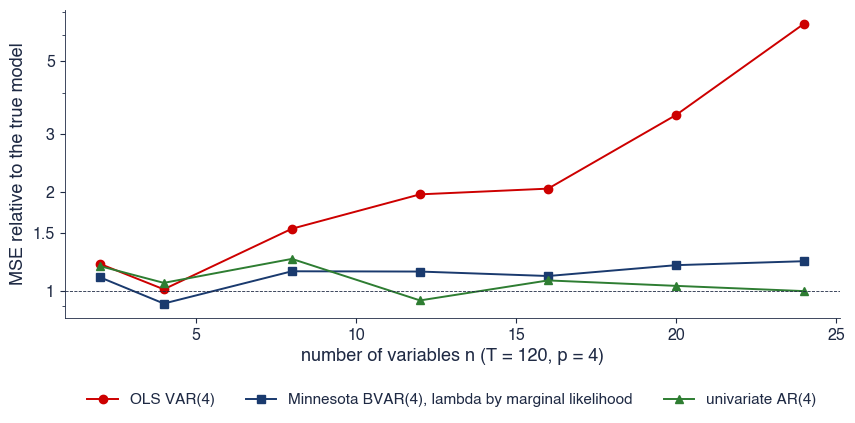

{'ns': [2, 4, 8, 12, 16, 20, 24], 'ols': [1.2093442000581687, 1.0119155586749338, 1.5450311432084, 1.9644092921346858, 2.0444605367114135, 3.4221080289043364, 6.478103403984023], 'bvar': [1.10125269166687, 0.9161751596590526, 1.1478240433053477, 1.145535172699319, 1.110430732350136, 1.197910466796806, 1.2315232675975571], 'ar': [1.1903345730568153, 1.0585194595241338, 1.2515738250963064, 0.9363581194347893, 1.0767492931692915, 1.0365064100383938, 0.9992215619258689], 'lam': [0.315534823809947, 0.22067362375843233, 0.16607230740071566, 0.14581726994707092, 0.13858649569069997, 0.13603574820887682, 0.14365738683595042], 'k': [9, 17, 33, 49, 65, 81, 97], 'T': 120, 'p': 4, 'reps': 50}


In [6]:
def sim_var(n, T, rng, rho=0.5, c=0.3, burn=100):
    """Stationary VAR(1) with common dynamics: A = rho I + (c/n) 11'; unit-variance Gaussian errors."""
    A = rho * np.eye(n) + c / n * np.ones((n, n))
    y = np.zeros((T + burn + 1, n))
    e = rng.standard_normal((T + burn + 1, n))
    for t in range(1, T + burn + 1):
        y[t] = A @ y[t - 1] + e[t]
    return y[burn:], A


def fig_curse(save_it=True, reps=200, T=120, p=4, ns=(2, 4, 8, 12, 16, 20, 24)):
    """One-step forecast MSE of variable 1, relative to the oracle (true A), for OLS VAR(p), a Minnesota BVAR(p)
    with lam chosen by the marginal likelihood (white-noise prior mean) and a univariate AR(p)."""
    rng = np.random.default_rng(SEED)
    res = {k: [] for k in ('ols', 'bvar', 'ar')}
    lams = []
    for n in ns:
        e = {k: [] for k in res}
        lm = []
        for _ in range(reps):
            y, A = sim_var(n, T + 1, rng)
            Yw, ynext = y[:-1], y[-1]
            oracle = A @ Yw[-1]
            Y, X = lagmat(Yw, p)
            Bo = np.linalg.lstsq(X, Y, rcond=None)[0]
            e['ols'].append((var_forecast(Bo, Yw, p, 1)[0, 0] - ynext[0]) ** 2 - (oracle[0] - ynext[0]) ** 2 + 1)
            delta = np.zeros(n)
            g = glp_optimize(Yw, p, delta, soc=False, dio=False)
            lm.append(g['lam'])
            po = bvar_fit(Yw, p, delta, g['lam'])
            e['bvar'].append((var_forecast(po['B'], Yw, p, 1)[0, 0] - ynext[0]) ** 2 - (oracle[0] - ynext[0]) ** 2 + 1)
            ya, Xa = lagmat(Yw[:, :1], p)
            ba = np.linalg.lstsq(Xa, ya, rcond=None)[0]
            e['ar'].append((var_forecast(ba, Yw[:, :1], p, 1)[0, 0] - ynext[0]) ** 2 - (oracle[0] - ynext[0]) ** 2 + 1)
        for k in res:
            res[k].append(float(np.mean(e[k])))
        lams.append(float(np.median(lm)))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ns, res['ols'], 'o-', color=st.IDAred, label=f'OLS VAR({p})')
    ax.plot(ns, res['bvar'], 's-', color=st.MainBlue, label=f'Minnesota BVAR({p}), lambda by marginal likelihood')
    ax.plot(ns, res['ar'], '^-', color=st.Forest, label=f'univariate AR({p})')
    ax.axhline(1, color=st.DarkText, lw=0.6, ls='--')
    ax.set_xlabel('number of variables n (T = 120, p = 4)')
    ax.set_ylabel('MSE relative to the true model')
    ax.set_yscale('log')
    plain_log_axis(ax, subs=(1.0, 1.5, 2.0, 3.0, 5.0))
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ats_ch5_curse', save_it)
    k = [n * p + 1 for n in ns]
    return dict(ns=list(ns), ols=res['ols'], bvar=res['bvar'], ar=res['ar'], lam=lams, k=k, T=T, p=p, reps=reps)


print(fig_curse(save_it=False, reps=50))

## 2. Bayesian inference: conjugate updating and Gibbs sampling

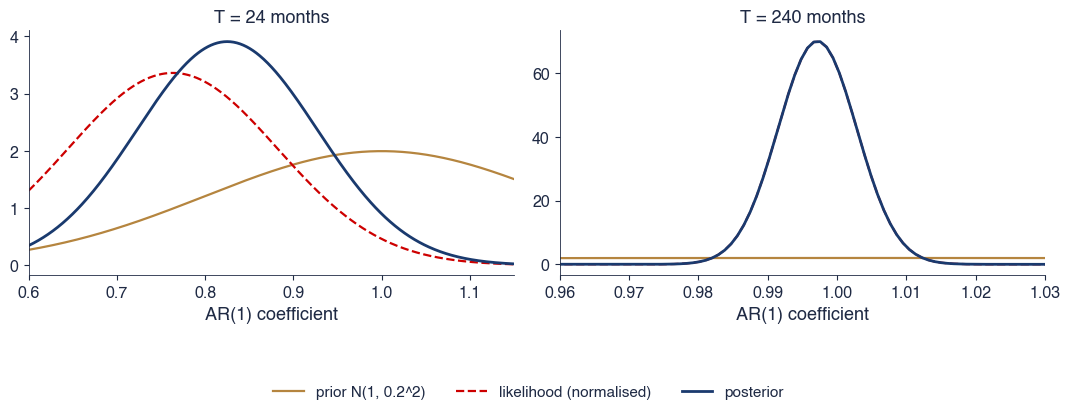

{'T24': {'ols': 0.7633587786259542, 'se': 0.11867523996353957, 'post': 0.8249818494047599, 'post_sd': 0.10206021165278387, 'w_prior': 0.260407170065276}, 'T240': {'ols': 0.9971739871288464, 'se': 0.005692483504843944, 'post': 0.9971762746547588, 'post_sd': 0.005690179138179671, 'w_prior': 0.0008094534656143783}}


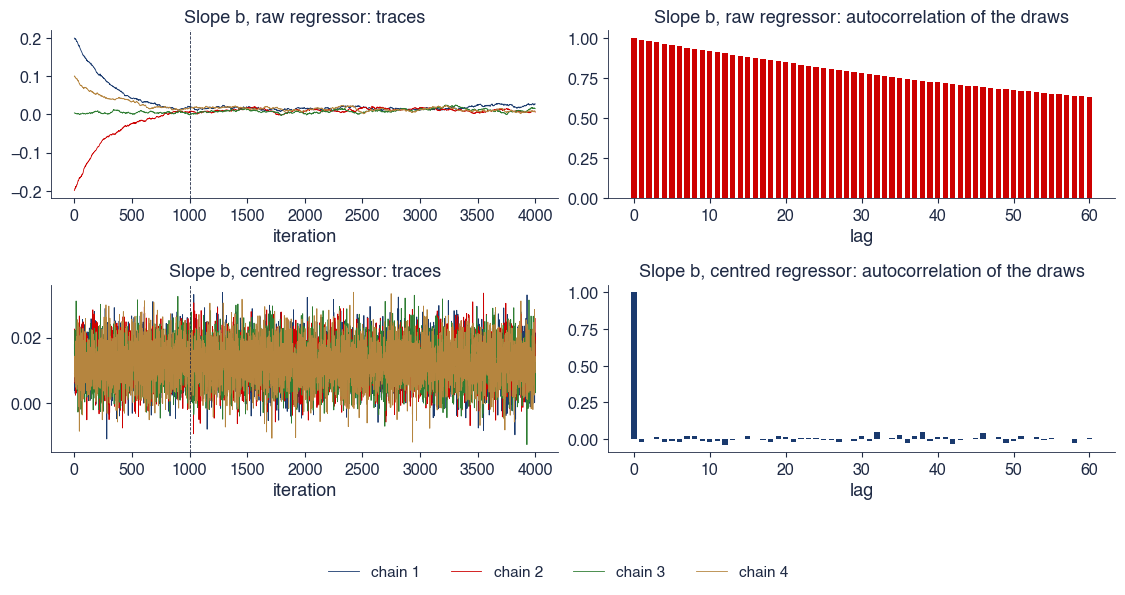

{'raw': {'mean': 0.012647620140576493, 'sd': 0.005438642366499383, 'q05': 0.004036060723259857, 'q95': 0.021706923117854625, 'ess': 52.55225920343824, 'rhat': 1.318965670345298, 'geweke': -2.268330809375226, 'acf1': 0.9918621584017965, 'corr_ab': -0.9977551517888082}, 'centred': {'mean': 0.012303754448217697, 'sd': 0.006138785559535856, 'q05': 0.002138176090711637, 'q95': 0.02239547475052476, 'ess': 11529.373762928932, 'rhat': 0.9998192764786045, 'geweke': 0.006995980701397367, 'acf1': -0.020139218955804082, 'corr_ab': -0.001306062394906452}, 'n_kept': 12000, 'T': 635, 'xmean': 78.96768614173229, 'xsd': 4.69981875383451}


In [7]:
def fig_conjugate(save_it=True, prior=(1.0, 0.2)):
    """Posterior of the AR(1) coefficient of the US unemployment rate (monthly, windows ending in December 2019)
    under the Minnesota-type prior N(1, 0.2^2), sigma^2 fixed at its OLS estimate: precision-weighted updating."""
    u = read_fred('UNRATE').loc[:'2019-12-01']
    out = {}
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
    grid = np.linspace(0.6, 1.15, 600)
    for ax, T in zip(axs, (24, 240)):
        y = u.values[-(T + 1):]
        x, yy = y[:-1] - y[:-1].mean(), y[1:] - y[1:].mean()
        rho_ols = float(x @ yy / (x @ x))
        s2 = float(np.mean((yy - rho_ols * x) ** 2))
        se = np.sqrt(s2 / (x @ x))
        m0, s0 = prior
        prec = 1 / s0 ** 2 + 1 / se ** 2
        m1 = (m0 / s0 ** 2 + rho_ols / se ** 2) / prec
        s1 = np.sqrt(1 / prec)
        w = (1 / s0 ** 2) / prec
        ax.plot(grid, stats.norm.pdf(grid, m0, s0), color=st.Amber, lw=1.6, label='prior N(1, 0.2^2)')
        ax.plot(grid, stats.norm.pdf(grid, rho_ols, se), color=st.IDAred, lw=1.6, ls='--', label='likelihood (normalised)')
        ax.plot(grid, stats.norm.pdf(grid, m1, s1), color=st.MainBlue, lw=2, label='posterior')
        ax.set_title(f'T = {T} months')
        ax.set_xlim(*((0.6, 1.15) if T == 24 else (0.96, 1.03)))
        ax.set_xlabel('AR(1) coefficient')
        out[f'T{T}'] = dict(ols=rho_ols, se=float(se), post=float(m1), post_sd=float(s1), w_prior=float(w))
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_conjugate', save_it)
    return out


def gibbs_regression(y, x, n_iter, start, rng, prior=(0.0, 100.0, 2.0, 1.0)):
    """Gibbs sampler, one coefficient at a time, for y = a + b x + e, e ~ N(0, s2), with independent priors
    a, b ~ N(m0, v0) and s2 ~ IG(a0, b0). Each step draws from a full conditional (Normal or inverse gamma)."""
    m0, v0, a0, b0 = prior
    a, b, s2 = start
    T = len(y)
    out = np.empty((n_iter, 3))
    for it in range(n_iter):
        r = y - b * x                                  # a | b, s2
        va = 1 / (1 / v0 + T / s2)
        a = rng.normal(va * (m0 / v0 + r.sum() / s2), np.sqrt(va))
        r = y - a                                      # b | a, s2
        vb = 1 / (1 / v0 + x @ x / s2)
        b = rng.normal(vb * (m0 / v0 + x @ r / s2), np.sqrt(vb))
        e = y - a - b * x                              # s2 | a, b
        s2 = 1 / rng.gamma(a0 + T / 2, 1 / (b0 + e @ e / 2))
        out[it] = a, b, s2
    return out


def acf(x, L):
    x = x - x.mean()
    v = x @ x
    return np.array([1.0] + [x[:-l] @ x[l:] / v for l in range(1, L + 1)])


def ess(x):
    """Effective sample size with Geyer's initial positive sequence."""
    r = acf(x, min(len(x) - 2, 2000))
    s = 0.0
    for k in range(1, len(r) - 1, 2):
        pair = r[k] + r[k + 1]
        if pair < 0:
            break
        s += pair
    return len(x) / (1 + 2 * s) if s > -0.5 else len(x)


def rhat(chains):
    """Gelman-Rubin potential scale reduction factor (split chains)."""
    c = np.concatenate([np.split(ch, 2) for ch in chains])
    n = c.shape[1]
    W = c.var(axis=1, ddof=1).mean()
    Bv = n * c.mean(axis=1).var(ddof=1)
    return float(np.sqrt(((n - 1) / n * W + Bv / n) / W))


def geweke(x, a=0.1, b=0.5):
    """Geweke z: mean of the first 10% against the last 50%, with spectral (Newey-West) variances."""
    def lrv(z):
        z = z - z.mean()
        L = int(4 * (len(z) / 100) ** (2 / 9)) + 1
        v = z @ z / len(z)
        for l in range(1, L + 1):
            v += 2 * (1 - l / (L + 1)) * (z[:-l] @ z[l:]) / len(z)
        return v / len(z)
    xa, xb = x[:int(a * len(x))], x[-int(b * len(x)):]
    return float((xa.mean() - xb.mean()) / np.sqrt(lrv(xa) + lrv(xb)))


def gibbs_data():
    """Monthly US industrial production growth (%) and the lagged capacity utilisation rate (%), 1967-2019."""
    ip = 100 * np.log(read_fred('INDPRO')).diff()
    cu = read_fred('CUMFNS').shift(1)
    d = pd.concat([ip, cu], axis=1, keys=['dip', 'cu']).loc['1967-02-01':'2019-12-01'].dropna()
    return d['dip'].values, d['cu'].values


def fig_gibbs(save_it=True, n_iter=4000, burn=1000, chains=4):
    """Gibbs sampling with the raw regressor (intercept and slope strongly correlated) and with the centred regressor:
    traces of the slope from four dispersed starting points, autocorrelation, ESS, R-hat and Geweke z."""
    y, x = gibbs_data()
    rng = np.random.default_rng(SEED)
    starts = [(-5.0, 0.2, 1.0), (5.0, -0.2, 1.0), (0.0, 0.0, 4.0), (2.0, 0.1, 0.5)]
    out = {}
    fig, axs = plt.subplots(2, 2, figsize=(11.5, 5.6))
    for row, (lab, xx) in enumerate((('raw regressor', x), ('centred regressor', x - x.mean()))):
        draws = [gibbs_regression(y, xx, n_iter, s, rng) for s in starts[:chains]]
        b = np.array([d[burn:, 1] for d in draws])
        for j, d in enumerate(draws):
            axs[row, 0].plot(d[:, 1], lw=0.6, color=st.PALETTE[j], label=f'chain {j + 1}')
        axs[row, 0].axvline(burn, color=st.DarkText, lw=0.6, ls='--')
        axs[row, 0].set_title(f'Slope b, {lab}: traces')
        axs[row, 0].set_xlabel('iteration')
        r = acf(b[0], 60)
        axs[row, 1].bar(np.arange(61), r, color=st.MainBlue if row else st.IDAred, width=0.7, label='_acf')
        axs[row, 1].set_title(f'Slope b, {lab}: autocorrelation of the draws')
        axs[row, 1].set_xlabel('lag')
        pooled = b.ravel()
        out['centred' if row else 'raw'] = dict(
            mean=float(pooled.mean()), sd=float(pooled.std()), q05=float(np.quantile(pooled, 0.05)),
            q95=float(np.quantile(pooled, 0.95)), ess=float(sum(ess(c) for c in b)), rhat=rhat(b),
            geweke=geweke(b[0]), acf1=float(r[1]), corr_ab=float(np.corrcoef(np.concatenate([d[burn:, 0] for d in draws]),
                                                                              pooled)[0, 1]))
    out['n_kept'] = chains * (n_iter - burn)
    out['T'] = int(len(y))
    out['xmean'] = float(x.mean())
    out['xsd'] = float(x.std())
    st.fig_legend_bottom(fig, [axs[0, 0].lines[j] for j in range(chains)], [f'chain {j + 1}' for j in range(chains)],
                         ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save('ats_ch5_gibbs', save_it)
    return out


print(fig_conjugate(save_it=False))
print(fig_gibbs(save_it=False))

## 3. Large BVARs: the marginal likelihood, the trade-off, Bańbura–Giannone–Reichlin

- `fig_bgr(step=12)` uses one forecast origin per year (the slides use every month).

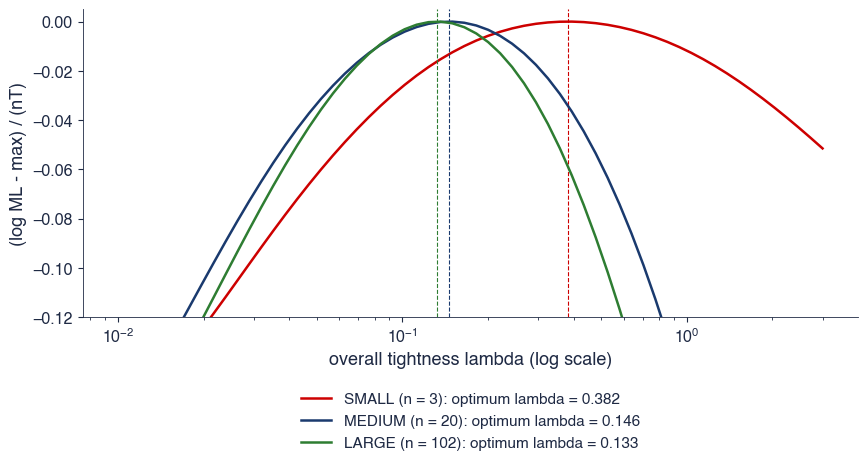

{'SMALL': {'n': 3, 'lam': 0.3823264247591727, 'lml': -215.16187791660207, 'T': 707, 'lml_02': -12.2846014594667, 'lml_1': -25.03009632353823, 'glp': {'lam': 0.380822714078308, 'mu': 0.19931643407888758, 'phi': 0.4396762772033556, 'logpost': -210.7425029810901}}, 'MEDIUM': {'n': 20, 'lam': 0.14630387568490782, 'lml': -10455.312878635414, 'T': 707, 'lml_02': -46.91642649217829, 'lml_1': -2177.785112904494, 'glp': {'lam': 0.14891580030557963, 'mu': 0.1337942631342278, 'phi': 0.4449495271410635, 'logpost': -10412.730586126874}}, 'LARGE': {'n': 102, 'lam': 0.13259310522792622, 'lml': -53976.81288567996, 'T': 707, 'lml_02': -597.2140639041318, 'lml_1': -15571.619170491438, 'glp': None}}


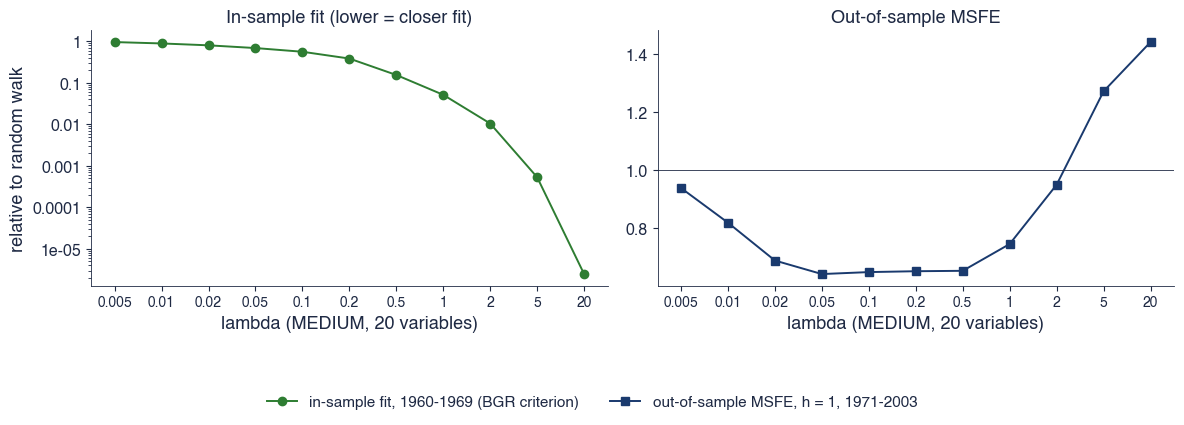

[0.9375595930717204, 0.8178892134132799, 0.6872657085672377, 0.6405845731628571, 0.6473968659901712, 0.6503812379119209, 0.6518005689257921, 0.7443050629105064, 0.9490008260642036, 1.271437768037309, 1.4414769538904821]


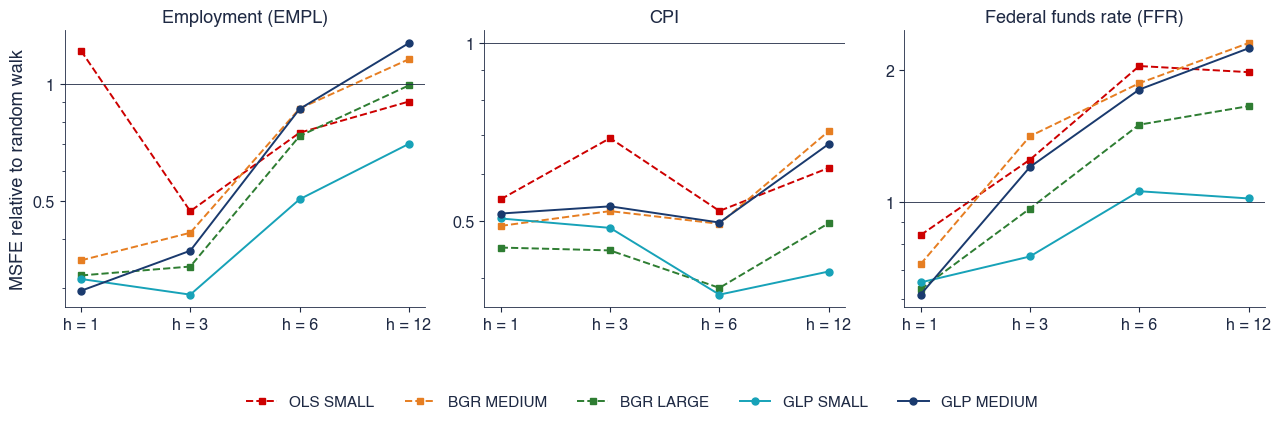

{'target': 0.4347517811123371, 'MEDIUM': 0.1577388601569243, 'LARGE': 0.058758758454038426} {'SMALL': {'median': 0.33632665885891105, 'q10': 0.2325962206335054, 'q90': 0.5383840767829966}, 'MEDIUM': {'median': 0.2823049865034986, 'q10': 0.23570380222988718, 'q90': 0.3242633299626711}}


In [8]:
def bgr_systems(raw):
    """SMALL, MEDIUM and LARGE systems: data (100 x log levels or levels) and the random-walk indicators delta."""
    out = {}
    for name, names in (('SMALL', SMALL), ('MEDIUM', MEDIUM),
                        ('LARGE', SMALL + [c for c in large_names(raw) if c not in SMALL])):
        out[name] = bvar_levels(raw, names, BGR['start'], END_M)
    return out


def bgr_scale(Yw, p):
    """Scale of the Minnesota prior in BGR (2010): residual variance of a univariate AR(p) for each variable."""
    return np.array([ar_var(Yw[:, i], p) for i in range(Yw.shape[1])])


def bgr_post(Yw, p, delta, lam, sig2=None):
    """BGR (2010) prior: Minnesota moments (eq. 2 with theta = 1) and the sum-of-coefficients prior with
    tau = 10 lam and mu_i = delta_i x the window mean of y_i (Section 3.3); lam = inf is OLS."""
    Yw = np.asarray(Yw, float)
    if np.isinf(lam):
        return bvar_fit(Yw, p, delta, lam)
    sig2 = bgr_scale(Yw, p) if sig2 is None else sig2
    return bvar_fit(Yw, p, delta, lam, soc_mu=10 * lam, sig2=sig2, soc_scale=delta * Yw.mean(0))


def insample_msfe(Yw, p, delta, lam, key=(0, 1, 2), sig2=None):
    """In-sample one-step mean squared error of the key variables (BGR 2010, Section 3); lam = 0 is the prior
    model (random walk with drift for delta = 1, white noise with mean for delta = 0)."""
    Yw = np.asarray(Yw, float)
    Y, X = lagmat(Yw, p)
    if lam == 0:
        pred = np.where(delta == 1, Yw[p - 1:-1] + np.diff(Yw, axis=0)[p - 1:].mean(0), Yw[p:].mean(0))
    else:
        pred = X @ bgr_post(Yw, p, delta, lam, sig2)['B']
    return np.mean((Y - pred) ** 2, axis=0)[list(key)]


def bgr_lambda(systems, grid=np.exp(np.linspace(np.log(1e-3), np.log(5), 70))):
    """lam of each system: in-sample fit on 1960:1-1969:12 equal to that of the SMALL VAR estimated by OLS."""
    p = BGR['p']
    Ys, ds = systems['SMALL']
    Ws = Ys.loc[:BGR['train_end']].values
    m0 = insample_msfe(Ws, p, ds, 0)
    target = float(np.mean(insample_msfe(Ws, p, ds, np.inf) / m0))
    out = {'target': target}
    for name in ('MEDIUM', 'LARGE'):
        Y, d = systems[name]
        W = Y.loc[:BGR['train_end']].values
        sig2 = bgr_scale(W, p)
        m0 = insample_msfe(W, p, d, 0)
        fits = np.array([np.mean(insample_msfe(W, p, d, lam, sig2=sig2) / m0) for lam in grid])
        out[name] = float(grid[np.argmin(np.abs(fits - target))])
    return out


def bgr_forecasts(raw=None, step=1, systems=None, lams=None, verbose=False):
    """Rolling 10-year windows, p = 13, iterated forecasts h = 1..12 of employment, CPI and the funds rate, origins
    1970:1 to the end of the sample (every `step` months). Models: random walk with drift, OLS SMALL, BGR MEDIUM and
    LARGE (lam by fit), GLP SMALL and MEDIUM (lam, mu, phi by the posterior mode, re-optimised each January)."""
    raw = fred_md_raw() if raw is None else raw
    systems = bgr_systems(raw) if systems is None else systems
    lams = bgr_lambda(systems) if lams is None else lams
    p, W, H = BGR['p'], BGR['window'], BGR['H']
    dates = systems['SMALL'][0].index
    origins = [t for t in dates[(dates >= '1970-01-01') & (dates < END_M)]][::step]
    rows = []
    glp_par = {}
    for T in origins:
        rec = {}
        for name in ('SMALL', 'MEDIUM', 'LARGE'):
            Y, d = systems[name]
            Yw = Y.loc[:T].values[-(W + p):]
            if name == 'SMALL':
                rec['RW'] = Yw[-1] + np.arange(1, H + 1)[:, None] * np.diff(Yw, axis=0).mean(0)
                rec['OLS SMALL'] = var_forecast(bgr_post(Yw, p, d, np.inf)['B'], Yw, p, H)
            else:
                rec[f'BGR {name}'] = var_forecast(bgr_post(Yw, p, d, lams[name])['B'], Yw, p, H)
            if name == 'LARGE':
                continue
            if T.month == 1 or name not in glp_par:
                g = glp_optimize(Yw, p, d)
                glp_par[name] = dict(lam=g['lam'], mu=g['mu'], phi=g['phi'])
                if verbose and name == 'MEDIUM':
                    print(T.date(), {k: round(v['lam'], 4) for k, v in glp_par.items()}, flush=True)
            gp = glp_par[name]
            po = bvar_fit(Yw, p, d, gp['lam'], soc_mu=gp['mu'], dio_phi=gp['phi'])
            rec[f'GLP {name}'] = var_forecast(po['B'], Yw, p, H)
        for m, fc in rec.items():
            for h in range(1, H + 1):
                rows.append(dict(origin=T, model=m, h=h, target=T + pd.DateOffset(months=h),
                                 **{v: fc[h - 1, i] for i, v in enumerate(SMALL)}))
        rows.append(dict(origin=T, model='_lam', h=0, target=T, **{f'lam_{k}': v['lam'] for k, v in glp_par.items()}))
    return pd.DataFrame(rows), lams, systems


def rel_msfe(F, actual, period, models=None, hs=(1, 3, 6, 12)):
    """MSFE relative to the random walk with drift, by model, variable and horizon, for targets in `period`."""
    F = F[F['model'] != '_lam']
    F = F[(F['target'] >= period[0]) & (F['target'] <= period[1])]
    out = {}
    for m in (models or sorted(F['model'].unique())):
        for h in hs:
            a = F[(F['model'] == m) & (F['h'] == h)].set_index('target')
            r = F[(F['model'] == 'RW') & (F['h'] == h)].set_index('target')
            for v in SMALL:
                y = actual[v].reindex(a.index)
                out[(m, v, h)] = float(np.mean((a[v] - y) ** 2) / np.mean((r[v] - y) ** 2))
    return out


def bgr_ordering(names):
    """Slow-moving variables, the funds rate, fast-moving variables (BGR 2010, Section 4)."""
    slow = [c for c in names if GROUP[c] not in FAST_GROUPS and c != 'FEDFUNDS']
    fast = [c for c in names if GROUP[c] in FAST_GROUPS and c != 'FEDFUNDS']
    return slow + ['FEDFUNDS'] + fast


def fig_lambda(save_it=True, grid=np.exp(np.linspace(np.log(0.01), np.log(3), 60)), end='2019-12-01'):
    """Log marginal likelihood (GLP 2015) of SMALL, MEDIUM and LARGE as a function of lam (mu = phi = 1), sample
    1960:1-2019:12, relative to its maximum: the optimal tightness falls as the system grows."""
    raw = fred_md_raw()
    systems = bgr_systems(raw)
    p = BGR['p']
    fig, ax = plt.subplots(figsize=(10, 4))
    out = {}
    for (name, (Y, d)), c in zip(systems.items(), (st.IDAred, st.MainBlue, st.Forest)):
        Yw = Y.loc[:end].values
        Y_, X_, s2, yb = bvar_setup(Yw, p, d)
        f = lambda lam: glp_logpost(Y_, X_, p, d, s2, yb, lam, 1.0, 1.0, hyper=False)
        lml = np.array([f(lam) for lam in grid])
        r = optimize.minimize_scalar(lambda z: -f(float(np.exp(z))), bounds=(np.log(1e-3), np.log(5)), method='bounded')
        lam_star, best = float(np.exp(r.x)), float(-r.fun)
        ax.plot(grid, (lml - best) / (len(Y_) * Y.shape[1]), color=c, lw=1.8,
                label=f'{name} (n = {Y.shape[1]}): optimum lambda = {lam_star:.3f}')
        ax.axvline(lam_star, color=c, lw=0.8, ls='--')
        g = glp_optimize(Yw, p, d) if name != 'LARGE' else None
        out[name] = dict(n=int(Y.shape[1]), lam=lam_star, lml=best, T=int(len(Y_)), lml_02=float(f(0.2) - best),
                         lml_1=float(f(1.0) - best), glp=g)
    ax.set_xscale('log')
    ax.set_ylim(-0.12, 0.005)
    ax.set_xlabel('overall tightness lambda (log scale)')
    ax.set_ylabel('(log ML - max) / (nT)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    save('ats_ch5_lambda', save_it)
    return out


def fig_tradeoff(save_it=True, grid=(0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 20.0), step=3):
    """MEDIUM system: in-sample fit and out-of-sample relative MSFE (h = 1, average over EMPL, CPI, FFR, targets
    1971-2003) as functions of lam: the bias-variance trade-off behind the choice of shrinkage."""
    raw = fred_md_raw()
    Y, d = bgr_systems(raw)['MEDIUM']
    p, W = BGR['p'], BGR['window']
    Wtr = Y.loc[:BGR['train_end']].values
    m0 = insample_msfe(Wtr, p, d, 0)
    dates = Y.index
    origins = [t for t in dates[(dates >= '1970-12-01') & (dates <= '2003-11-01')]][::step]
    fit, oos = [], []
    for lam in grid:
        fit.append(float(np.mean(insample_msfe(Wtr, p, d, lam) / m0)))
        e, er = [], []
        for T in origins:
            Yw = Y.loc[:T].values[-(W + p):]
            nxt = Y.loc[T + pd.DateOffset(months=1)].values[:3]
            fc = var_forecast(bgr_post(Yw, p, d, lam)['B'], Yw, p, 1)[0, :3]
            rw = Yw[-1, :3] + np.diff(Yw, axis=0).mean(0)[:3]
            e.append((fc - nxt) ** 2)
            er.append((rw - nxt) ** 2)
        oos.append(float(np.mean(np.mean(e, 0) / np.mean(er, 0))))
    lab = [f'{g:g}' for g in grid]
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    x = np.arange(len(grid))
    axs[0].plot(x, fit, 'o-', color=st.Forest, label='in-sample fit, 1960-1969 (BGR criterion)')
    axs[0].set_yscale('log')
    plain_log_axis(axs[0], subs=(1.0,))
    axs[0].set_title('In-sample fit (lower = closer fit)')
    axs[1].plot(x, oos, 's-', color=st.MainBlue, label='out-of-sample MSFE, h = 1, 1971-2003')
    axs[1].axhline(1, color=st.DarkText, lw=0.6)
    axs[1].set_title('Out-of-sample MSFE')
    for ax in axs:
        ax.set_xticks(x)
        ax.set_xticklabels(lab, fontsize=10)
        ax.set_xlabel('lambda (MEDIUM, 20 variables)')
    axs[0].set_ylabel('relative to random walk')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_tradeoff', save_it)
    i = int(np.argmin(oos))
    return dict(grid=list(grid), fit=fit, oos=oos, best=float(grid[i]), best_oos=oos[i], loose_oos=oos[-1],
                loose_fit=fit[-1], tight_oos=oos[0], step=step, n_origins=len(origins),
                k=int(Y.shape[1] * p + 1), T=W)


def fig_bgr(save_it=True, step=1):
    """Relative MSFE (random walk with drift = 1) of employment, CPI and the funds rate, targets 1971-2003."""
    raw = fred_md_raw()
    F, lams, systems = bgr_forecasts(raw, step=step)
    actual = systems['SMALL'][0]
    r1 = rel_msfe(F, actual, BGR['eval1'])
    r2 = rel_msfe(F, actual, BGR['eval2'])
    r3 = rel_msfe(F, actual, (BGR['eval2'][0], '2019-12-01'))
    models = ['OLS SMALL', 'BGR MEDIUM', 'BGR LARGE', 'GLP SMALL', 'GLP MEDIUM']
    cols = [st.IDAred, st.Orange, st.Forest, st.Teal, st.MainBlue]
    labels = {'USPRIV': 'Employment (EMPL)', 'CPIAUCSL': 'CPI', 'FEDFUNDS': 'Federal funds rate (FFR)'}
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.9))
    hs = (1, 3, 6, 12)
    for ax, v in zip(axs, SMALL):
        for m, c in zip(models, cols):
            ax.plot(range(4), [r1[(m, v, h)] for h in hs], 'o-' if m.startswith('GLP') else 's--', color=c, label=m,
                    lw=1.4, ms=5)
        ax.axhline(1, color=st.DarkText, lw=0.6)
        ax.set_xticks(range(4))
        ax.set_xticklabels([f'h = {h}' for h in hs])
        ax.set_title(labels[v])
        ax.set_yscale('log')
        plain_log_axis(ax)
    axs[0].set_ylabel('MSFE relative to random walk')
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_bgr', save_it)
    L = F[F['model'] == '_lam']
    return dict(lam_fit=lams, n_large=int(systems['LARGE'][0].shape[1]), n_medium=len(MEDIUM),
                k_large=int(systems['LARGE'][0].shape[1] * BGR['p'] + 1), n_origins=int(len(L)),
                glp_lam={k: dict(median=float(L[f'lam_{k}'].median()), q10=float(L[f'lam_{k}'].quantile(0.1)),
                                 q90=float(L[f'lam_{k}'].quantile(0.9))) for k in ('SMALL', 'MEDIUM')},
                eval1={f'{m}|{v}|{h}': x for (m, v, h), x in r1.items()},
                eval2={f'{m}|{v}|{h}': x for (m, v, h), x in r2.items()},
                pre2020={f'{m}|{v}|{h}': x for (m, v, h), x in r3.items()}, step=step)


print(fig_lambda(save_it=False))
print(fig_tradeoff(save_it=False, step=12)['oos'])
r = fig_bgr(save_it=False, step=12)
print(r['lam_fit'], r['glp_lam'])

## 4. Responses to a monetary policy shock with posterior bands; common volatility

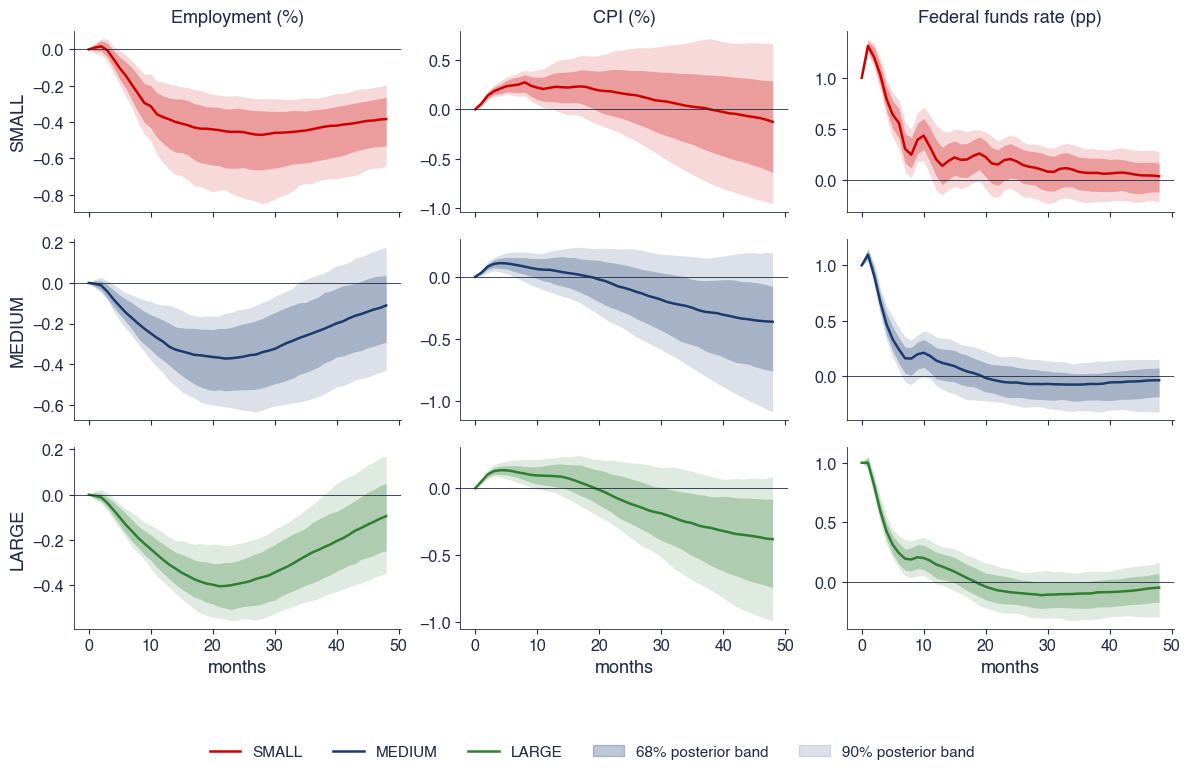

{'n': 102, 'lam': 0.058758758454038426, 'emp_min': -0.40477903225997103, 'emp_arg': 21, 'emp12': -0.28794705950112554, 'emp12_lo': -0.38494386555072757, 'emp12_hi': -0.16828527719242362, 'emp48': -0.09486257122223596, 'emp48_lo': -0.3472919741653251, 'emp48_hi': 0.17222177459241694, 'cpi_max': 0.13437250334996442, 'cpi_argmax': 4, 'cpi48': -0.37970768274698136, 'cpi48_lo': -0.9870210518294017, 'cpi48_hi': 0.08835054699674691, 'ffr12': 0.1474660145999283, 'ndraw': 200}


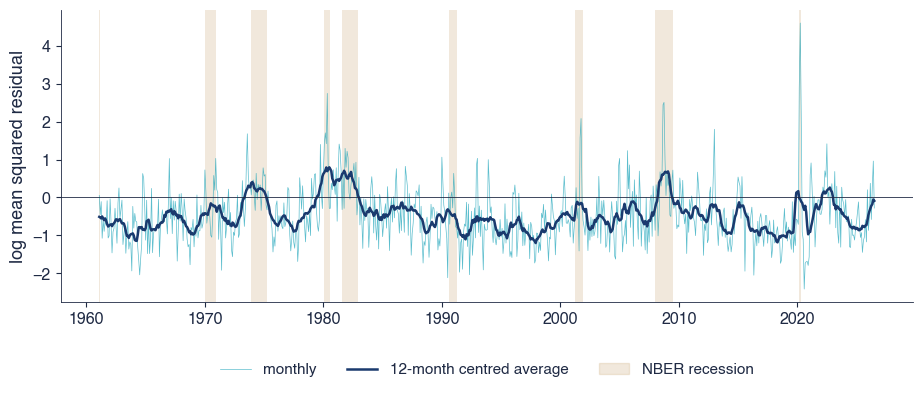

{'lam': 0.20938505334483576, 'mu': 0.10724216435037379, 'phi': 0.3921819962810329, 'ratio_gm': 1.276157261443829, 'peak': 4.599688127029404, 'peak_date': '2020-04-01', 'ratio_peak': 176.2788004625147, 'share_tail': 0.004834605597964376}


In [9]:
def fig_bvar_irf(save_it=True, ndraw=500, lams=None):
    """Responses to a 100 bp funds-rate shock, recursive slow/fast scheme, BGR prior with sum-of-coefficients,
    p = 13, sample 1961-2002; posterior medians with 68% and 90% bands, for SMALL, MEDIUM and LARGE."""
    raw = fred_md_raw()
    systems = bgr_systems(raw)
    lams = bgr_lambda(systems) if lams is None else lams
    p, H = BGR['p'], BGR['Hirf']
    rng = np.random.default_rng(SEED)
    fig, axs = plt.subplots(3, 3, figsize=(12, 7.4), sharex=True)
    out = {}
    hh = np.arange(H + 1)
    show = {'USPRIV': 'Employment (%)', 'CPIAUCSL': 'CPI (%)', 'FEDFUNDS': 'Federal funds rate (pp)'}
    for row, (name, c) in enumerate(zip(('SMALL', 'MEDIUM', 'LARGE'), (st.IDAred, st.MainBlue, st.Forest))):
        Y, d = systems[name]
        order = bgr_ordering(list(Y.columns))
        Yo = Y[order].loc[BGR['irf'][0]:BGR['irf'][1]]
        do = np.array([d[list(Y.columns).index(cn)] for cn in order])
        n = Yo.shape[1]
        k = order.index('FEDFUNDS')
        # SMALL: a nearly flat prior (lam = 1000), the Bayesian counterpart of the OLS VAR of BGR Table 1
        lam = 1e3 if name == 'SMALL' else lams[name]
        po = bvar_fit(Yo.values, p, do, lam) if name == 'SMALL' else bgr_post(Yo.values, p, do, lam)
        draws = []
        for _ in range(ndraw):
            B, Sig = niw_draw(po, rng)
            draws.append(irf_shock(B, recursive_impact(Sig, k), n, p, H))
        q = np.quantile(np.array(draws), [0.05, 0.16, 0.5, 0.84, 0.95], axis=0)
        for col, v in enumerate(SMALL):
            i = order.index(v)
            ax = axs[row, col]
            band_plot(ax, hh, q[2][:, i], q[0][:, i], q[4][:, i], c, f'{name}: posterior median', q[1][:, i], q[3][:, i])
            if row == 0:
                ax.set_title(show[v])
            if row == 2:
                ax.set_xlabel('months')
        axs[row, 0].set_ylabel(name)
        iE, iP = order.index('USPRIV'), order.index('CPIAUCSL')
        med = q[2]
        out[name] = dict(n=n, lam=lam, emp_min=float(med[:, iE].min()), emp_arg=int(med[:, iE].argmin()),
                         emp12=float(med[12, iE]), emp12_lo=float(q[0][12, iE]), emp12_hi=float(q[4][12, iE]),
                         emp48=float(med[48, iE]), emp48_lo=float(q[0][48, iE]), emp48_hi=float(q[4][48, iE]),
                         cpi_max=float(med[:24, iP].max()), cpi_argmax=int(med[:24, iP].argmax()),
                         cpi48=float(med[48, iP]), cpi48_lo=float(q[0][48, iP]), cpi48_hi=float(q[4][48, iP]),
                         ffr12=float(med[12, k]), ndraw=ndraw)
    st.fig_legend_bottom(fig, [axs[r, 0].lines[0] for r in range(3)] + [patch(st.MainBlue, 0.28), patch(st.MainBlue, 0.15)],
                         ['SMALL', 'MEDIUM', 'LARGE', '68% posterior band', '90% posterior band'], ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    save('ats_ch5_bvar_irf', save_it)
    return out


def fig_common_vol(save_it=True):
    """Common volatility proxy: log of the cross-sectional mean of squared standardised residuals of the MEDIUM BVAR
    (GLP hyperparameters, 1960-2026), 12-month centred moving average; NBER recessions shaded."""
    raw = fred_md_raw()
    Y, d = bgr_systems(raw)['MEDIUM']
    p = BGR['p']
    g = glp_optimize(Y.values, p, d)
    po = bvar_fit(Y.values, p, d, g['lam'], soc_mu=g['mu'], dio_phi=g['phi'])
    Yr, X = lagmat(Y.values, p)
    E = Yr - X @ po['B']
    E = E / E.std(0)
    v = pd.Series(np.log(np.mean(E ** 2, 1)), index=Y.index[p:])
    vs = v.rolling(12, center=True, min_periods=6).mean()
    rec = read_fred('USREC').loc[vs.index[0]:vs.index[-1]]
    fig, ax = plt.subplots(figsize=(11, 3.8))
    recessions(ax, rec)
    l1, = ax.plot(v.index, v, color=st.Teal, lw=0.5, alpha=0.7)
    l2, = ax.plot(vs.index, vs, color=st.MainBlue, lw=1.8)
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('log mean squared residual')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16, handles=[l1, l2, patch(st.Amber, 0.18)],
                             labels=['monthly', '12-month centred average', 'NBER recession'])
    save('ats_ch5_common_vol', save_it)
    early, mod = v.loc['1960-01-01':'1984-12-01'].mean(), v.loc['1985-01-01':'2007-12-01'].mean()
    return dict(lam=g['lam'], mu=g['mu'], phi=g['phi'], ratio_gm=float(np.exp(early - mod)),
                peak=float(v.max()), peak_date=str(v.idxmax().date()), ratio_peak=float(np.exp(v.max() - v.median())),
                share_tail=float(np.mean(np.abs(E) > 4)))


print(fig_bvar_irf(save_it=False, ndraw=200)['LARGE'])
print(fig_common_vol(save_it=False))

## 5. The same optimisation with a package

In [10]:
# Comparison with a package: bvar (Bank of England, MIT licence) implements the GLP (2015) optimisation for the
# natural conjugate model (it also estimates the lag decay c3). In Colab the package is installed here; elsewhere the
# cell runs only if bvar is already installed.
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'bvar'], check=False)
try:
    from bvar import BVAR, NaturalConjugate
    Ys = bgr_systems(fred_md_raw())['SMALL'][0].loc[:'2019-12-01'].copy()
    Ys.index = Ys.index.to_period('M')
    pk = BVAR(n_lags=13, model=NaturalConjugate(soc=True, sur=True), stationary=False, random_state=1)
    pk.optimise_hyperparameters(Ys, optimisation_backend='numpy')
    ours = glp_optimize(bgr_systems(fred_md_raw())['SMALL'][0].loc[:'2019-12-01'].values, 13,
                        bgr_systems(fred_md_raw())['SMALL'][1])
    print('package bvar: lambda = %.3f, lag decay = %.2f, mu = %.3f, phi = %.3f' % (pk.model.pars.c1, pk.model.pars.c3,
                                                                                   pk.model.pars.mu, pk.model.pars.theta))
    print('numpy (lag decay fixed at 2): lambda = %.3f, mu = %.3f, phi = %.3f' % (ours['lam'], ours['mu'], ours['phi']))
except ImportError:
    print('bvar is not installed: run this notebook in Colab, or pip install bvar')

bvar is not installed: run this notebook in Colab, or pip install bvar


## 6. Factors of the FRED-MD panel and diffusion-index forecasts

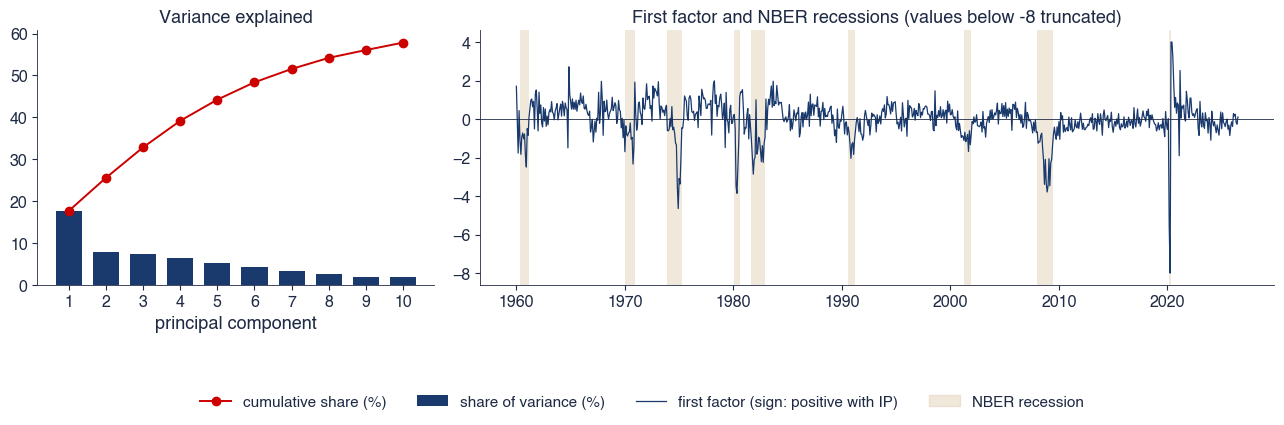

{'N': 117, 'T': 799, 'first': '1960-01-01', 'last': '2026-07-01', 'miss': 0.04476749783383075, 'share': [0.17572655513759466, 0.0792001935497738, 0.07292351217928024, 0.0636158664039507, 0.050679522553096885, 0.041507866507165, 0.031901204578513545, 0.02653324610910574, 0.0186965708493758, 0.017766679769298393], 'k': {'IC_p1': 8, 'IC_p2': 8, 'IC_p3': 10, 'PC_p1': 13, 'PC_p2': 11}, 'cum5': 0.44214564982369625, 'cum8': 0.5420879670184806, 'corr_rec': -0.5794566889457214, 'min_date': '2020-04-01', 'n_out': 3}


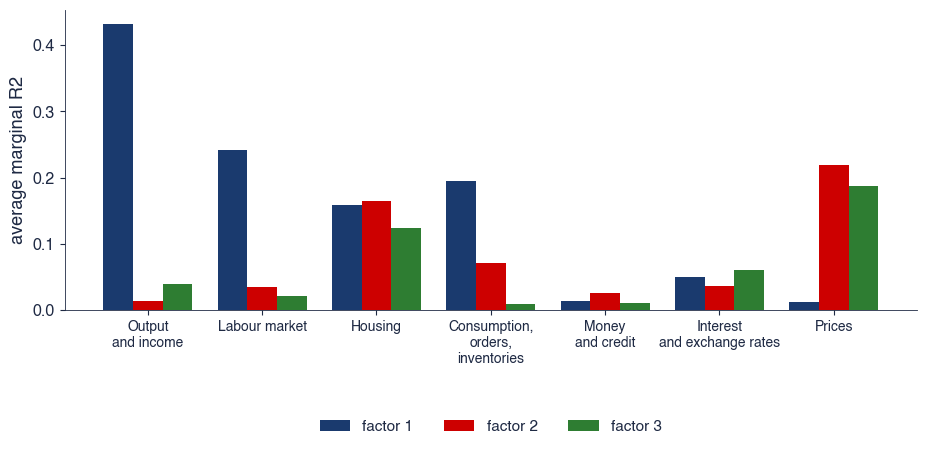

[('IPMANSICS', 0.7760743050855423), ('INDPRO', 0.7328158889045491), ('IPFPNSS', 0.7082977226093591)]


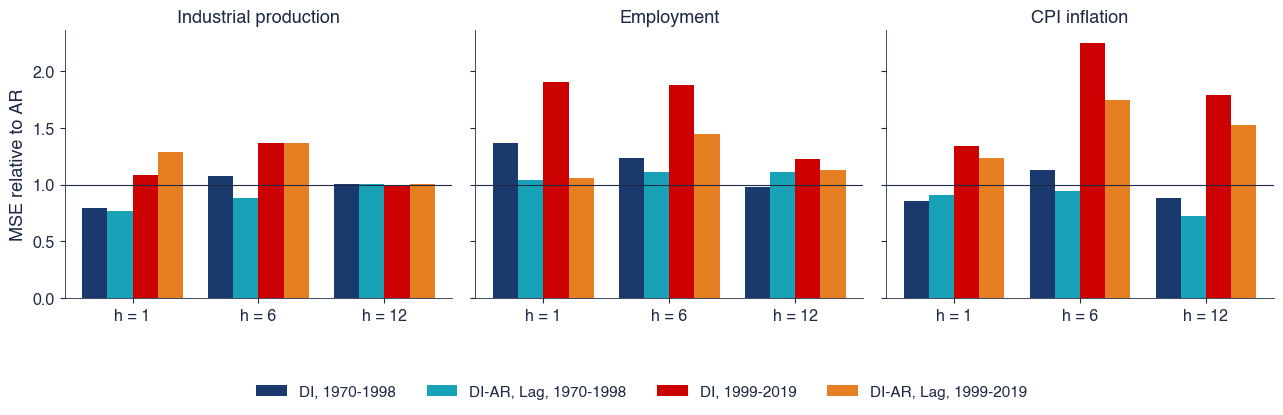

{'CPIAUCSL|1|AR': 1.0, 'CPIAUCSL|1|DI': 0.8570679490678401, 'CPIAUCSL|1|DI-AR, Lag': 0.9066583274820813, 'CPIAUCSL|6|AR': 1.0, 'CPIAUCSL|6|DI': 1.1318061674236333, 'CPIAUCSL|6|DI-AR, Lag': 0.9390609009372771, 'CPIAUCSL|12|AR': 1.0, 'CPIAUCSL|12|DI': 0.8834775273450453, 'CPIAUCSL|12|DI-AR, Lag': 0.7195972152888993, 'INDPRO|1|AR': 1.0, 'INDPRO|1|DI': 0.7920543223629527, 'INDPRO|1|DI-AR, Lag': 0.7684868067512802, 'INDPRO|6|AR': 1.0, 'INDPRO|6|DI': 1.0721167486305934, 'INDPRO|6|DI-AR, Lag': 0.8790724847749285, 'INDPRO|12|AR': 1.0, 'INDPRO|12|DI': 1.0032327774364542, 'INDPRO|12|DI-AR, Lag': 1.0036360458149196, 'PAYEMS|1|AR': 1.0, 'PAYEMS|1|DI': 1.367983269052659, 'PAYEMS|1|DI-AR, Lag': 1.040893212563352, 'PAYEMS|6|AR': 1.0, 'PAYEMS|6|DI': 1.2363200929601292, 'PAYEMS|6|DI-AR, Lag': 1.1066907646771025, 'PAYEMS|12|AR': 1.0, 'PAYEMS|12|DI': 0.982997150461393, 'PAYEMS|12|DI-AR, Lag': 1.1131263177484088}


In [11]:
def di_target(level, tc, h):
    """Stock and Watson (2002, JBES): y^h_{t+h} = (1200/h) ln(Y_{t+h}/Y_t) for real series (code 5) and
    (1200/h) ln(P_{t+h}/P_t) - 1200 ln(P_t/P_{t-1}) for prices (code 6); z_t is the monthly regressor."""
    lx = np.log(level)
    yh = 1200 / h * (lx.shift(-h) - lx)
    z = 1200 * lx.diff()
    if tc == 6:
        yh = yh - z
        z = z.diff()
    return yh, z


def bic_ols(y, X):
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    n = len(y)
    return np.log(e @ e / n) + X.shape[1] * np.log(n) / n, b


def di_forecasts(H=SW['H'], step=1, kmax=SW['kmax'], pmax=SW['pmax'], targets=SW['targets']):
    """Recursive pseudo out-of-sample forecasts from 1970:1: AR (BIC lags 0..pmax), DI (BIC factors 1..kmax) and
    DI-AR, Lag (BIC over factors and lags), factors re-estimated at each origin by EM principal components on the panel
    observed up to the origin (outliers removed with the information available)."""
    raw = fred_md_raw()
    Xall = pd.DataFrame({c: transform(raw[c], TCODE[c]) for c in raw.columns if c in TCODE}).loc['1960-01-01':END_M]
    tg = {v: {h: di_target(raw[v].loc[:END_M], TCODE[v], h) for h in H} for v in targets}
    dates = Xall.index
    origins = [t for t in dates[(dates >= SW['start']) & (dates < END_M)]][::step]
    rows = []
    for T in origins:
        Xt = remove_outliers(Xall.loc[:T])
        Xt = Xt.loc[:, (Xt.notna().sum() > 36) & (Xt.std() > 0)]
        F, *_ = em_pca(Xt.values, kmax, maxit=30)
        F = pd.DataFrame(F, index=Xt.index)
        for v in targets:
            for h in H:
                yh, z = tg[v][h]
                Zl = pd.concat([z.shift(j) for j in range(pmax + 1)], axis=1).loc[Xt.index]
                yy = yh.loc[Xt.index]
                ok = yy.notna() & Zl.notna().all(1) & (yy.index <= T - pd.DateOffset(months=h))
                if ok.sum() < 60:
                    continue
                yv, Zv, Fv = yy[ok].values, Zl[ok].values, F[ok].values
                one = np.ones((ok.sum(), 1))
                zT, fT = Zl.loc[T].values, F.loc[T].values
                best = {}
                best['AR'] = min((bic_ols(yv, np.hstack([one, Zv[:, :p + 1]]))[0], p) for p in range(pmax + 1))
                best['DI'] = min((bic_ols(yv, np.hstack([one, Fv[:, :k]]))[0], k) for k in range(1, kmax + 1))
                best['DI-AR, Lag'] = min((bic_ols(yv, np.hstack([one, Fv[:, :k], Zv[:, :p + 1]]))[0], k, p)
                                         for k in range(1, kmax + 1) for p in range(pmax + 1))
                p = best['AR'][1]
                fc = {'AR': np.r_[1, zT[:p + 1]] @ bic_ols(yv, np.hstack([one, Zv[:, :p + 1]]))[1]}
                k = best['DI'][1]
                fc['DI'] = np.r_[1, fT[:k]] @ bic_ols(yv, np.hstack([one, Fv[:, :k]]))[1]
                _, k, p = best['DI-AR, Lag']
                fc['DI-AR, Lag'] = np.r_[1, fT[:k], zT[:p + 1]] @ bic_ols(yv, np.hstack([one, Fv[:, :k], Zv[:, :p + 1]]))[1]
                for m, f in fc.items():
                    rows.append(dict(origin=T, var=v, h=h, model=m, fc=float(f), actual=float(yh.loc[T]),
                                     k=best['DI'][1] if m == 'DI' else (best['DI-AR, Lag'][1] if m == 'DI-AR, Lag' else 0)))
    return pd.DataFrame(rows)


def di_rel(D, period):
    D = D[(D['origin'] >= period[0]) & (D['origin'] <= period[1])].dropna(subset=['actual'])
    out = {}
    for (v, h), g in D.groupby(['var', 'h']):
        mse = {m: np.mean((x['fc'] - x['actual']) ** 2) for m, x in g.groupby('model')}
        for m in mse:
            out[(v, h, m)] = float(mse[m] / mse['AR'])
    return out


def fig_factors(save_it=True, r=8, kmax=15):
    """FRED-MD-style panel 1960:1-2026:7: EM principal components, share of variance of the first components,
    Bai-Ng criteria, the first factor against NBER recessions."""
    X = fred_md_panel()
    F, L, Z, mu, sd = em_pca(X.values, r)
    bn = bai_ng(Z, kmax)
    f1 = pd.Series(F[:, 0], index=X.index)
    ip = X['INDPRO']
    if np.corrcoef(f1.values[ip.notna().values], ip.dropna().values)[0, 1] < 0:
        f1 = -f1
    rec = read_fred('USREC').loc[X.index[0]:X.index[-1]]
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1, 2]))
    ks = np.arange(1, 11)
    axs[0].bar(ks, 100 * bn['share'][:10], color=st.MainBlue, width=0.7, label='share of variance (%)')
    axs[0].plot(ks, 100 * np.cumsum(bn['share'][:10]), 'o-', color=st.IDAred, label='cumulative share (%)')
    axs[0].set_xticks(ks)
    axs[0].set_xlabel('principal component')
    axs[0].set_title('Variance explained')
    recessions(axs[1], rec)
    axs[1].plot(f1.index, f1.clip(-8, 4), color=st.MainBlue, lw=0.9, label='first factor (sign: positive with IP)')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_title('First factor and NBER recessions (values below -8 truncated)')
    h0, l0 = axs[0].get_legend_handles_labels()
    h1, l1 = axs[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h0 + h1 + [patch(st.Amber, 0.18)], l0 + l1 + ['NBER recession'], ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_factors', save_it)
    corr_rec = float(np.corrcoef(f1.loc[rec.index], rec)[0, 1])
    return dict(N=int(X.shape[1]), T=int(X.shape[0]), first=str(X.index[0].date()), last=str(X.index[-1].date()),
                miss=float(np.isnan(X.values).mean()), share=[float(x) for x in bn['share'][:10]], k=bn['k'],
                cum5=float(np.sum(bn['share'][:5])), cum8=float(np.sum(bn['share'][:8])), corr_rec=corr_rec,
                min_date=str(f1.idxmin().date()), n_out=int((remove_outliers(X).isna() & X.notna()).sum().sum()))


def fig_mr2(save_it=True, r=3):
    """Marginal R2 of each of the first r factors by group of series (McCracken and Ng 2016, Figure 1 style)."""
    X = fred_md_panel()
    F, L, Z, mu, sd = em_pca(X.values, 8)
    obs = ~np.isnan(X.values)
    R2 = np.zeros((X.shape[1], r))
    for i in range(X.shape[1]):
        z = Z[obs[:, i], i]
        for j in range(r):
            f = F[obs[:, i], j]
            R2[i, j] = np.corrcoef(z, f)[0, 1] ** 2
    g = np.array([GROUP[c] for c in X.columns])
    fig, ax = plt.subplots(figsize=(11, 3.9))
    w = 0.26
    out = {}
    for j, c in zip(range(r), (st.MainBlue, st.IDAred, st.Forest)):
        vals = [R2[g == k, j].mean() for k in GROUPS]
        ax.bar(np.arange(len(GROUPS)) + (j - 1) * w, vals, width=w, color=c, label=f'factor {j + 1}')
        out[f'f{j + 1}'] = {GROUPS[k]: float(v) for k, v in zip(GROUPS, vals)}
        top = np.argsort(-R2[:, j])[:3]
        out[f'top{j + 1}'] = [(X.columns[i], float(R2[i, j])) for i in top]
    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels([GROUPS[k].replace(', ', ',\n').replace(' and ', '\nand ') for k in GROUPS], fontsize=10)
    ax.set_ylabel('average marginal R2')
    st.legend_outside_bottom(ax, ncol=3, y=-0.32)
    save('ats_ch5_mr2', save_it)
    return out


def fig_di(save_it=True, step=1):
    """Relative MSE (AR = 1) of diffusion-index forecasts of IP, employment and CPI inflation, h = 1, 6, 12, for the
    original evaluation period 1970-1998 (by forecast origin) and 1999-2026."""
    D = di_forecasts(step=step)
    r1, r2 = di_rel(D, SW['eval1']), di_rel(D, SW['eval2'])
    r3 = di_rel(D, ('1999-01-01', '2019-12-01'))
    names = {'INDPRO': 'Industrial production', 'PAYEMS': 'Employment', 'CPIAUCSL': 'CPI inflation'}
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
    w = 0.2
    for ax, v in zip(axs, SW['targets']):
        for j, (m, per, c, lab) in enumerate((('DI', r1, st.MainBlue, 'DI, 1970-1998'), ('DI-AR, Lag', r1, st.Teal, 'DI-AR, Lag, 1970-1998'),
                                              ('DI', r3, st.IDAred, 'DI, 1999-2019'), ('DI-AR, Lag', r3, st.Orange, 'DI-AR, Lag, 1999-2019'))):
            ax.bar(np.arange(3) + (j - 1.5) * w, [per[(v, h, m)] for h in SW['H']], width=w, color=c, label=lab)
        ax.axhline(1, color=st.DarkText, lw=0.8)
        ax.set_xticks(range(3))
        ax.set_xticklabels([f'h = {h}' for h in SW['H']])
        ax.set_title(names[v])
    axs[0].set_ylabel('MSE relative to AR')
    st.fig_legend_bottom(fig, *axs[0].get_legend_handles_labels(), ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_di', save_it)
    kk = D[(D['model'] == 'DI-AR, Lag') & (D['h'] == 12)]['k']
    return dict(eval1={f'{v}|{h}|{m}': x for (v, h, m), x in r1.items()},
                eval2={f'{v}|{h}|{m}': x for (v, h, m), x in r2.items()},
                pre2020={f'{v}|{h}|{m}': x for (v, h, m), x in r3.items()},
                k_median=float(kk.median()), k_q10=float(kk.quantile(0.1)), k_q90=float(kk.quantile(0.9)),
                n_origins=int(D['origin'].nunique()), step=step)


print(fig_factors(save_it=False))
print(fig_mr2(save_it=False)['top1'])
print(fig_di(save_it=False, step=12)['eval1'])

## 7. FAVAR (Bernanke, Boivin and Eliasz 2005)

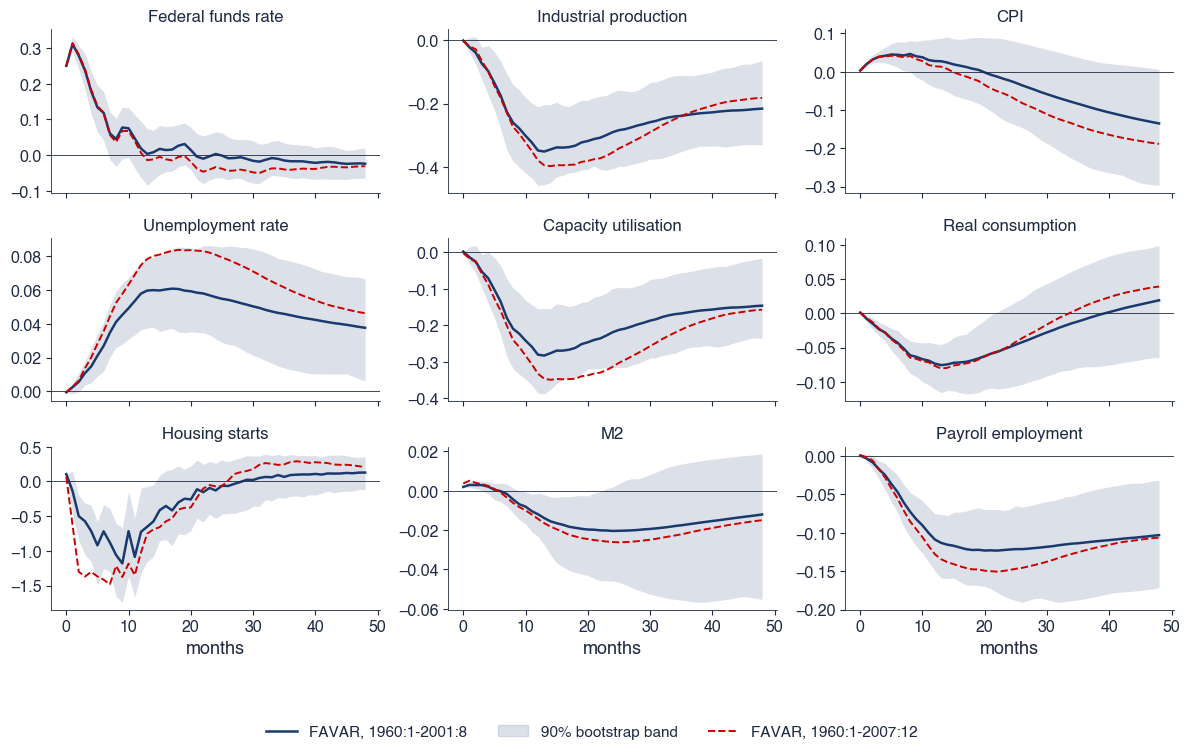

{'h12': -0.3477658143977418, 'h48': -0.21599044700470865, 'lo48': -0.329297253503287, 'hi48': -0.06542154010833462, 'min': -0.3509596067105297, 'argmin': 13, 'max': -0.0015917119231452347, 'argmax': 0, 'h48_2': -0.18224327179328237, 'max_2': -0.0034336624815271}


In [12]:
def favar_data(end):
    """BBE (2005) panel: balanced transformed series 1960:1-end, standardised; slow-moving series; the funds rate."""
    raw = fred_md_raw()
    # prices, wages and money enter as monthly growth rates (code 6 -> 5), so that level responses cumulate once
    X = pd.DataFrame({c: transform(raw[c], 5 if TCODE[c] == 6 else TCODE[c]) for c in raw.columns if c in TCODE})
    X = X.loc[BBE['start']:end]
    X = X.loc[:, X.notna().all()]
    X = X.drop(columns=[c for c in X.columns if c == 'FEDFUNDS'])
    Z = (X - X.mean()) / X.std()
    slow = [c for c in Z.columns if GROUP[c] not in FAST_GROUPS]
    return Z, slow, raw['FEDFUNDS'].loc[BBE['start']:end], X.std()


def favar_estimate(Z, slow, ffr, K):
    """Two-step FAVAR of BBE (2005, Section III): C = first K+1... principal components of all series; slow factors
    from the slow-moving series; F = C - b_Y Y from the regression of C on the slow factors and the funds rate."""
    def pcs(M, k):
        U, s, Vt = np.linalg.svd(M, full_matrices=False)
        return np.sqrt(len(M)) * U[:, :k]
    C = pcs(Z.values, K)
    Fs = pcs(Z[slow].values, K)
    y = ffr.values
    R = np.column_stack([np.ones(len(y)), Fs, y])
    b = np.linalg.lstsq(R, C, rcond=None)[0]
    F = C - np.outer(y, b[-1])
    S = np.column_stack([F, y])
    Lam = np.linalg.lstsq(np.column_stack([np.ones(len(y)), S]), Z.values, rcond=None)[0][1:]
    return S, Lam


def ols_var(S, p):
    Y, X = lagmat(S, p)
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    U = Y - X @ B
    return B, U, U.T @ U / (len(U) - X.shape[1])


def favar_irf_obs(B, Sig, Lam, sd, cols, K, p, H):
    """Responses of the observed series to a 25 bp funds-rate shock: loadings times the factor responses, rescaled to
    the original units and cumulated for differenced series."""
    k = K
    imp = recursive_impact(Sig, k) * 0.25
    th = irf_shock(B, imp, K + 1, p, H)
    out = {}
    for c, _ in FAVAR_SHOW:
        if c == 'FEDFUNDS':
            out[c] = th[:, k]
            continue
        j = cols.index(c)
        x = th @ Lam[:, j] * sd[c]
        tc = 5 if TCODE[c] == 6 else TCODE[c]
        if tc in (2, 5):
            x = np.cumsum(x)
        elif tc in (3, 6):
            x = np.cumsum(np.cumsum(x))
        out[c] = x * (100 if tc in (4, 5, 6) else 1)
    return out


def favar_run(end, K, B=BBE['B'], seed=SEED):
    """Point responses and residual-bootstrap 90% bands (the factors are treated as data, as in BBE)."""
    Z, slow, ffr, sd = favar_data(end)
    p, H = BBE['p'], BBE['H']
    S, Lam = favar_estimate(Z, slow, ffr, K)
    Bv, U, Sig = ols_var(S, p)
    cols = list(Z.columns)
    pt = favar_irf_obs(Bv, Sig, Lam, sd, cols, K, p, H)
    rng = np.random.default_rng(seed)
    Yl, X = lagmat(S, p)
    draws = {c: [] for c in pt}
    for _ in range(B):
        idx = rng.integers(0, len(U), len(U))
        Sb = np.zeros_like(S)
        Sb[:p] = S[:p]
        for t in range(p, len(S)):
            x = np.concatenate([Sb[t - j] for j in range(1, p + 1)] + [[1.0]])
            Sb[t] = x @ Bv + U[idx[t - p]]
        Bb, Ub, Sb_ = ols_var(Sb, p)
        r = favar_irf_obs(Bb, Sb_, Lam, sd, cols, K, p, H)
        for c in r:
            draws[c].append(r[c])
    bands = {c: np.quantile(np.array(v), [0.05, 0.95], axis=0) for c, v in draws.items()} if B else None
    return pt, bands, dict(T=int(len(S)), N=int(Z.shape[1]), Nslow=len(slow))


def fig_favar(save_it=True, B=BBE['B']):
    """BBE (2005): K = 3 factors and the funds rate, VAR(13), 1960:1-2001:8; responses to a 25 bp shock with 90%
    bootstrap bands; dashed: the sample extended to 2007:12."""
    pt, bd, info = favar_run(BBE['end'], BBE['K'], B=B)
    pt2, _, info2 = favar_run(BBE['end2'], BBE['K'], B=0)
    H = BBE['H']
    hh = np.arange(H + 1)
    fig, axs = plt.subplots(3, 3, figsize=(12, 7.2), sharex=True)
    out = dict(info=info, info2=info2)
    for ax, (c, lab), col in zip(axs.ravel(), FAVAR_SHOW, st.PALETTE * 2):
        band_plot(ax, hh, pt[c], bd[c][0], bd[c][1], st.MainBlue, 'FAVAR, 1960-2001')
        ax.plot(hh, pt2[c], color=st.IDAred, lw=1.4, ls='--', label='FAVAR, 1960-2007')
        ax.set_title(lab, fontsize=12)
        out[c] = dict(h12=float(pt[c][12]), h48=float(pt[c][48]), lo48=float(bd[c][0][48]), hi48=float(bd[c][1][48]),
                      min=float(pt[c].min()), argmin=int(pt[c].argmin()), max=float(pt[c].max()),
                      argmax=int(pt[c].argmax()), h48_2=float(pt2[c][48]), max_2=float(pt2[c][:24].max()))
    for ax in axs[-1]:
        ax.set_xlabel('months')
    st.fig_legend_bottom(fig, [axs[0, 0].lines[0], patch(st.MainBlue, 0.15), axs[0, 0].lines[-1]],
                         ['FAVAR, 1960:1-2001:8', '90% bootstrap band', 'FAVAR, 1960:1-2007:12'], ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    save('ats_ch5_favar', save_it)
    return out


print(fig_favar(save_it=False, B=100)['INDPRO'])

## 8. Nowcasting Romanian GDP

- The pseudo-real-time evaluation with the EM estimator takes a few minutes; here it runs without it (`em=False`).

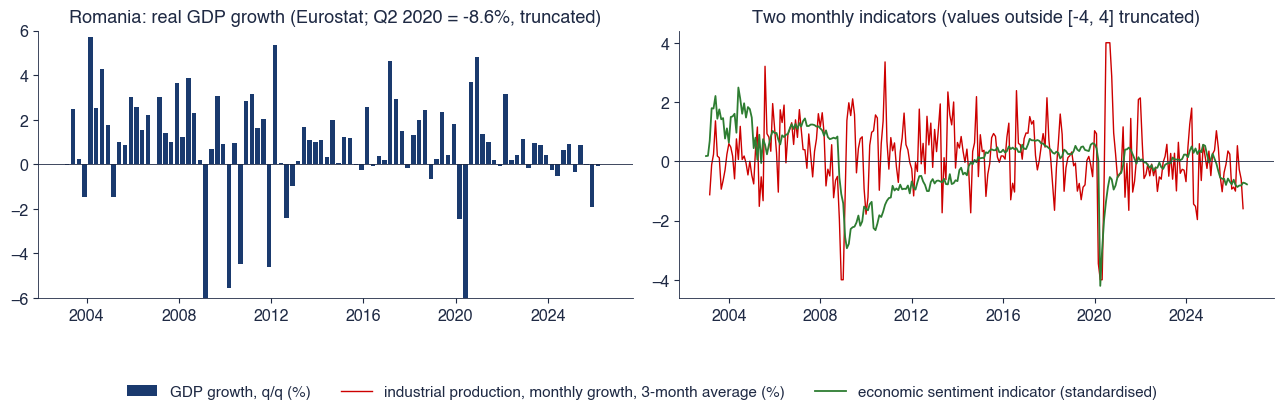

{'first_q': '2003-03-01', 'last_q': '2026-06-01', 'n_q': 94, 'last_y': 0.00048382765722720933, 'prev_y': -0.0633614988053921, 'y2020q2': -8.6062191593129, 'sd_y': 2.4453967190678614, 'corr_esi': 0.4388845218080862, 'last': {'ip': '2026-07-01', 'retail': '2026-07-01', 'constr': '2026-07-01', 'ip_ea': '2026-07-01', 'unemp': '2026-08-01', 'esi': '2026-09-01', 'ici': '2026-09-01', 'sci': '2026-09-01', 'rci': '2026-09-01', 'bci': '2026-09-01', 'cci': '2026-09-01'}, 'N': 11}


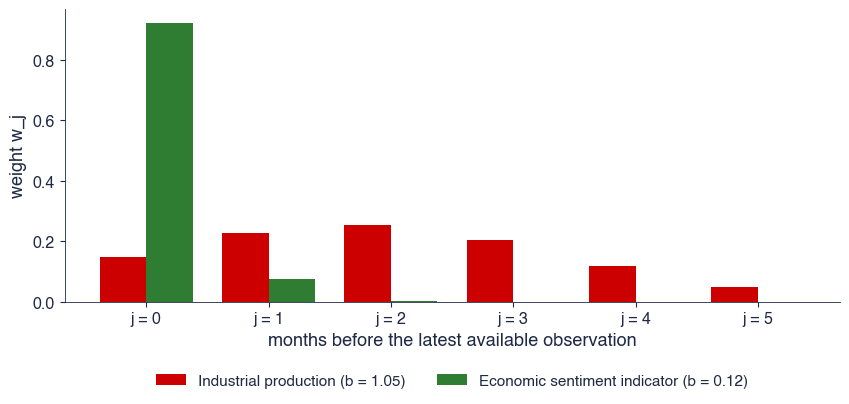

{'theta': [-11.18837125611121, 1.0507520280996667, 0.5995270380776392, -0.16411419672283842, 0.11943910115956227, -1.9999999999999998, -0.49999999999999994, -0.28348712219518307], 'ip': {'w': [0.14764886888088286, 0.22820624164605904, 0.2540253935457522, 0.20364744562999915, 0.11757988231636443, 0.048892167980942376], 'b': 1.0507520280996667}, 'esi': {'w': [0.9220062044030173, 0.07568287801964786, 0.002285424886063869, 2.5388777147696356e-05, 1.0375812930473467e-07, 1.5599403818677318e-10], 'b': 0.11943910115956227}, 'rho': -0.28348712219518307}


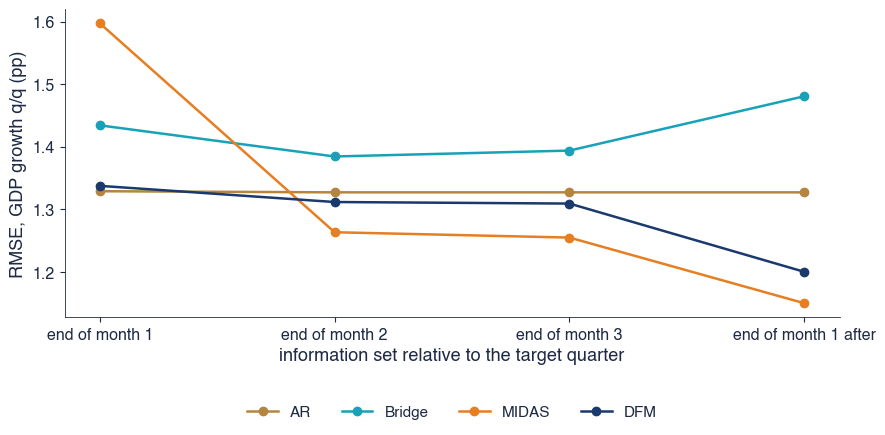

{'AR|M+1': 1.3269867729525737, 'AR|M1': 1.3287922506936805, 'AR|M2': 1.3269867729525737, 'AR|M3': 1.3269867729525737, 'Bridge|M+1': 1.480597526562816, 'Bridge|M1': 1.4341238606750675, 'Bridge|M2': 1.3843207996763425, 'Bridge|M3': 1.3937444550652907, 'DFM|M+1': 1.1999030483846582, 'DFM|M1': 1.337375014494174, 'DFM|M2': 1.3115168560751849, 'DFM|M3': 1.3090347276787493, 'MIDAS|M+1': 1.149718652047752, 'MIDAS|M1': 1.5973782082076038, 'MIDAS|M2': 1.2631973979124578, 'MIDAS|M3': 1.2546735353230634}


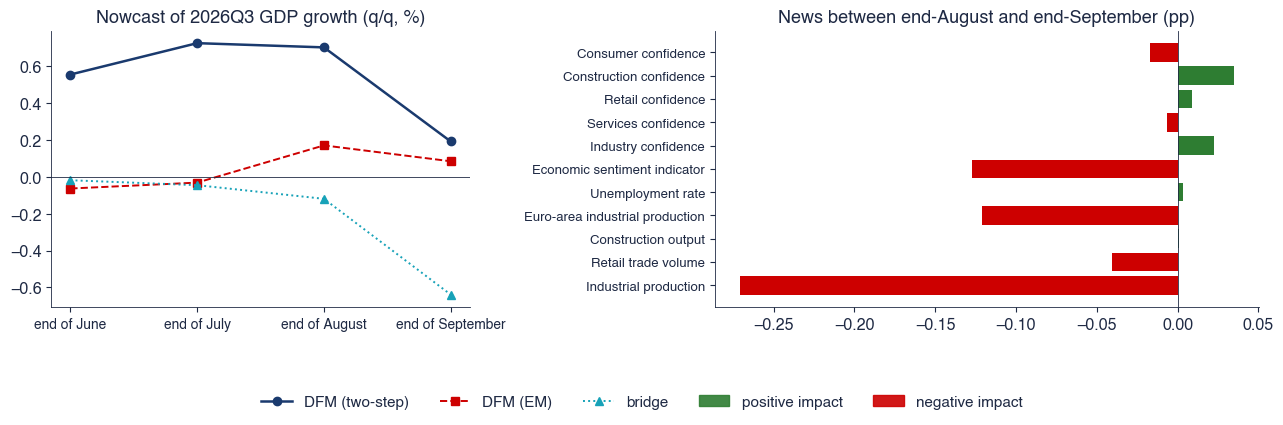

0.7027906944962605 0.18933472597340573 {'ip': -0.27092180997136533, 'retail': -0.04074730175301517, 'constr': 0.0009575559053564517, 'ip_ea': -0.12112579397808737, 'unemp': 0.0034029998184654745, 'esi': -0.12747462002043977, 'ici': 0.022224244459534012, 'sci': -0.006641497977555944, 'rci': 0.009181202174778375, 'bci': 0.03501740046550901, 'cci': -0.017328347646034168}


In [13]:
def mshift(d, k):
    return pd.Timestamp(d) + pd.DateOffset(months=k)


def ro_vintage(X, y, V, lags=None, gdp_lag=RO['gdp_lag']):
    """Information set at the end of month V with stylised publication lags (months): series k is known up to
    V - lag_k, GDP of a quarter up to its third month <= V - gdp_lag. Data revisions are ignored (pseudo real time)."""
    lags = lags or {k: v[1] for k, v in RO_SPEC.items()}
    V = pd.Timestamp(V)
    Xv = X.loc[:V].copy()
    for k in Xv.columns:
        Xv.loc[Xv.index > mshift(V, -lags[k]), k] = np.nan
    return Xv, y[y.index <= mshift(V, -gdp_lag)]


def dfm_fit(Xv, yv, r=RO['r'], pf=2):
    """Two-step estimator of Doz, Giannone and Reichlin (2011): principal components on the balanced part of the
    standardised monthly panel, OLS loadings, a VAR(pf) for the factors, and the GDP loading on the Mariano-Murasawa
    aggregate of the factors (quarterly growth = (1, 2, 3, 2, 1)/3 applied to the monthly factor)."""
    mu, sd = Xv.mean(), Xv.std()
    Zf = (Xv - mu) / sd
    bal = Zf.dropna()
    U, s, Vt = np.linalg.svd(bal.values, full_matrices=False)
    f = np.sqrt(len(bal)) * U[:, :r]
    if np.corrcoef(f[:, 0], bal['ip'].values)[0, 1] < 0:
        f = -f
    Lam = np.linalg.lstsq(f, bal.values, rcond=None)[0].T
    psi = np.var(bal.values - f @ Lam.T, axis=0)
    Yf, Xf = lagmat(f, pf, const=False)
    A = np.linalg.lstsq(Xf, Yf, rcond=None)[0].T
    Qu = np.cov((Yf - Xf @ A.T).T).reshape(r, r)
    fs = pd.DataFrame(f, index=bal.index)
    agg = sum(MM[j] * fs.shift(j) for j in range(5))
    ys = (yv - yv.mean()) / yv.std()
    ok = agg.index.intersection(ys.index)
    ok = [t for t in ok if agg.loc[t].notna().all()]
    G = agg.loc[ok].values
    ly = np.linalg.lstsq(G, ys.loc[ok].values, rcond=None)[0]
    psi_y = float(np.var(ys.loc[ok].values - G @ ly))
    return dict(mu=mu, sd=sd, Lam=Lam, psi=np.maximum(psi, 1e-3), A=A, Q=Qu, ly=ly, psi_y=max(psi_y, 1e-3),
                my=float(yv.mean()), sy=float(yv.std()), r=r, pf=pf, cols=list(Xv.columns))


def dfm_matrices(par, ns=6):
    """State s_t = (f_t, ..., f_{t-ns+1}); transition and the GDP row of the measurement equation."""
    r, pf = par['r'], par['pf']
    m = r * ns
    Tm = np.zeros((m, m))
    for l in range(pf):
        Tm[:r, l * r:(l + 1) * r] = par['A'][:, l * r:(l + 1) * r]
    Tm[r:, :-r] = np.eye(m - r)
    Q = np.zeros((m, m))
    Q[:r, :r] = par['Q']
    zy = np.zeros(m)
    for j in range(5):
        zy[j * r:(j + 1) * r] = MM[j] * par['ly']
    return Tm, Q, zy


def kalman_dfm(par, Xv, yv, end, ns=6):
    """Kalman filter with missing data (rows of missing observations dropped): monthly series standardised with the
    estimated means and sds, quarterly GDP in the third month. Returns filtered states and covariances to `end`."""
    r = par['r']
    Tm, Q, zy = dfm_matrices(par, ns)
    m = len(Tm)
    idx = pd.date_range(Xv.index[0], pd.Timestamp(end), freq='MS')
    Z = ((Xv.reindex(idx) - par['mu']) / par['sd'])[par['cols']].values
    ys = ((yv - par['my']) / par['sy']).reindex(idx).values
    Lf = np.zeros((len(par['cols']), m))
    Lf[:, :r] = par['Lam']
    s, P = np.zeros(m), np.eye(m) * 10.0
    S, PP = [], []
    for t in range(len(idx)):
        s, P = Tm @ s, Tm @ P @ Tm.T + Q
        ok = ~np.isnan(Z[t])
        H = Lf[ok]
        obs = Z[t, ok]
        R = par['psi'][ok]
        if not np.isnan(ys[t]):
            H = np.vstack([H, zy])
            obs = np.append(obs, ys[t])
            R = np.append(R, par['psi_y'])
        if len(obs):
            F = H @ P @ H.T + np.diag(R)
            K = P @ H.T @ np.linalg.inv(F)
            s = s + K @ (obs - H @ s)
            P = P - K @ H @ P
        S.append(s.copy())
        PP.append(P.copy())
    return idx, np.array(S), np.array(PP)


def dfm_nowcast(Xv, yv, target, V, r=RO['r'], pf=2, par=None):
    """GDP growth of the quarter ending in month `target` given the information set at the end of month V."""
    par = par or dfm_fit(Xv, yv, r, pf)
    target = pd.Timestamp(target)
    end = max(target, pd.Timestamp(V))
    idx, S, _ = kalman_dfm(par, Xv, yv, end)
    off = (end.year - target.year) * 12 + end.month - target.month
    Tm, Q, zy = dfm_matrices(par)
    zz = np.roll(zy, off * par['r'])
    return float(par['my'] + par['sy'] * zz @ S[-1]), par


def dfm_em_nowcast(Xv, yv, target, r=RO['r'], pf=2):
    """Quasi-maximum likelihood (EM) estimation of the same model with statsmodels DynamicFactorMQ (Banbura and
    Modugno 2014), idiosyncratic AR(1) components; nowcast = prediction of quarterly GDP in month `target`."""
    from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ
    Xm = Xv.copy()
    Xm.index = Xm.index.to_period('M')
    yq = yv.copy()
    yq.index = yq.index.to_period('Q')
    mod = DynamicFactorMQ(Xm, endog_quarterly=yq.to_frame('gdp'), factors=r, factor_orders=pf, idiosyncratic_ar1=True)
    res = mod.fit(disp=False, maxiter=300)
    tp = pd.Timestamp(target).to_period('M')
    last = Xm.index[-1]
    if tp > last:
        p = res.predict(start=last, end=tp)
    else:
        p = res.predict(start=tp, end=tp)
    return float(p['gdp'].loc[tp]), res


def ar_nowcast(yv, target):
    """AR(1) for quarterly GDP growth, iterated from the last published quarter to the target."""
    y = yv.values
    b = np.polyfit(y[:-1], y[1:], 1)
    last = yv.index[-1]
    steps = ((pd.Timestamp(target).year - last.year) * 12 + pd.Timestamp(target).month - last.month) // 3
    x = y[-1]
    for _ in range(steps):
        x = b[1] + b[0] * x
    return float(x)


def fill_ar(x, end, p=2):
    """Monthly series extended to `end` with iterated AR(p) forecasts (bridge equations)."""
    s = x.dropna()
    yy, Xl = lagmat(s.values[:, None], p)
    b = np.linalg.lstsq(Xl, yy, rcond=None)[0][:, 0]
    vals = list(s.values)
    idx = list(s.index)
    while idx[-1] < pd.Timestamp(end):
        xx = np.r_[[vals[-j] for j in range(1, p + 1)], 1.0]
        vals.append(float(xx @ b))
        idx.append(mshift(idx[-1], 1))
    return pd.Series(vals, index=idx)


def quarter_agg(x, kind):
    """Quarterly aggregate in the third month: Mariano-Murasawa sum for monthly growth rates, mean for levels."""
    if kind == 'dlog':
        return sum(MM[j] * x.shift(j) for j in range(5))
    return x.rolling(3).mean()


def bridge_nowcast(Xv, yv, target):
    """Bridge equation: the monthly indicators (IP and retail growth, the ESI) are completed to the end of the target
    quarter with AR(2) forecasts, aggregated to the quarter and related to GDP growth by OLS."""
    cols = []
    for k in BRIDGE:
        x = fill_ar(Xv[k], target)
        cols.append(quarter_agg(x, RO_SPEC[k][2]).rename(k))
    A = pd.concat(cols, axis=1)
    q = [t for t in yv.index if t in A.index and A.loc[t].notna().all()]
    Xr = np.column_stack([np.ones(len(q)), A.loc[q].values])
    b = np.linalg.lstsq(Xr, yv.loc[q].values, rcond=None)[0]
    return float(np.r_[1, A.loc[pd.Timestamp(target)].values] @ b)


def almon(theta, K):
    j = np.arange(K)
    w = np.exp(theta[0] * j + theta[1] * j ** 2)
    return w / w.sum()


def midas_design(Xv, yv, target, V, K=RO['K']):
    """Rows of the ADL-MIDAS regression with leads: for each quarter, the K most recent monthly values of each
    indicator available at the same position of the quarter as V, and the latest published GDP growth."""
    lags = {k: v[1] for k, v in RO_SPEC.items()}
    gap = (pd.Timestamp(target).year - pd.Timestamp(V).year) * 12 + pd.Timestamp(target).month - pd.Timestamp(V).month
    ylag = 1 if gap <= 1 else 2                    # latest published quarter relative to the target
    rows, ys, keys = [], [], []
    quarters = list(yv.index) + [pd.Timestamp(target)]
    for qm in quarters:
        r = []
        for k in MIDAS_X:
            a = mshift(qm, -gap - lags[k])
            vals = [Xv[k].get(mshift(a, -j), np.nan) for j in range(K)]
            r.append(vals)
        yl = yv.get(mshift(qm, -3 * ylag), np.nan)
        rows.append((np.array(r), yl))
        ys.append(yv.get(qm, np.nan))
        keys.append(qm)
    return rows, np.array(ys), keys


def midas_fit(rows, ys, K=RO['K']):
    """Nonlinear least squares of y = b0 + sum_k b_k sum_j w_j(theta_k) x_{k,j} + rho y_lag, exponential Almon weights."""
    ok = [i for i, ((Xr, yl), yy) in enumerate(zip(rows, ys)) if np.isfinite(yy) and np.isfinite(yl) and np.isfinite(Xr).all()]
    Xr = np.array([rows[i][0] for i in ok])
    yl = np.array([rows[i][1] for i in ok])
    yy = ys[ok]
    nk = len(MIDAS_X)

    def pred(th, Xr, yl):
        out = th[0] + th[-1] * yl
        for k in range(nk):
            out = out + th[1 + 3 * k] * Xr[:, k, :] @ almon(th[2 + 3 * k:4 + 3 * k], K)
        return out
    x0 = np.zeros(2 + 3 * nk)
    lo = np.r_[-np.inf, [v for _ in range(nk) for v in (-np.inf, -2.0, -0.5)], -np.inf]
    hi = np.r_[np.inf, [v for _ in range(nk) for v in (np.inf, 2.0, 0.5)], np.inf]
    r = optimize.least_squares(lambda th: pred(th, Xr, yl) - yy, x0, bounds=(lo, hi))
    return r.x, pred


def midas_nowcast(Xv, yv, target, V, ret_par=False):
    rows, ys, keys = midas_design(Xv, yv, target, V)
    th, pred = midas_fit(rows, ys)
    Xr, yl = rows[-1]
    if not np.isfinite(yl):
        yl = float(yv.iloc[-1])
    Xr = np.where(np.isfinite(Xr), Xr, 0.0)
    f = float(pred(th, Xr[None], np.array([yl]))[0])
    return (f, th) if ret_par else f


def nowcast_eval(quarters=None, em=True, models=('AR', 'Bridge', 'MIDAS', 'DFM'), lags=None, r=RO['r'], start=None,
                 vintages=(-2, -1, 0, 1), period=RO['eval']):
    """Pseudo-real-time nowcasts of each quarter (third month m) at the ends of months m-2, m-1, m and m+1."""
    X, y = ro_panel()
    if start:
        X, y = X.loc[start:], y.loc[start:]
    quarters = quarters or [t for t in y.index if pd.Timestamp(period[0]) <= t <= pd.Timestamp(period[1])]
    rows = []
    for m in quarters:
        for off, lab in zip(vintages, RO['vintages']):
            V = mshift(m, off)
            Xv, yv = ro_vintage(X, y, V, lags)
            rec = {}
            if 'AR' in models:
                rec['AR'] = ar_nowcast(yv, m)
            if 'Bridge' in models:
                rec['Bridge'] = bridge_nowcast(Xv, yv, m)
            if 'MIDAS' in models:
                rec['MIDAS'] = midas_nowcast(Xv, yv, m, V)
            if 'DFM' in models:
                rec['DFM'] = dfm_nowcast(Xv, yv, m, V, r=r)[0]
            if em:
                try:
                    rec['DFM (EM)'] = dfm_em_nowcast(Xv, yv, m)[0]
                except Exception:
                    rec['DFM (EM)'] = np.nan
            for k, v in rec.items():
                rows.append(dict(quarter=m, vintage=lab, model=k, fc=v, actual=float(y.loc[m])))
    return pd.DataFrame(rows)


def nowcast_rmse(D, covid=True):
    if not covid:
        D = D[~D['quarter'].isin([pd.Timestamp('2020-06-01'), pd.Timestamp('2020-09-01')])]
    return {(m, v): float(np.sqrt(np.mean((g['fc'] - g['actual']) ** 2))) for (m, v), g in D.groupby(['model', 'vintage'])}


def news_decomposition(old_V, new_V, target):
    """Banbura and Modugno (2014) news: with the parameters estimated at the old vintage, the revision of the nowcast
    equals sum_j w_j (x_j - E[x_j | old]) over the new releases j, with w = E[y I'] E[I I']^{-1}."""
    X, y = ro_panel()
    Xo, yo = ro_vintage(X, y, old_V)
    Xn, yn = ro_vintage(X, y, new_V)
    par = dfm_fit(Xo, yo)
    target = pd.Timestamp(target)
    end = max(target, pd.Timestamp(new_V))
    idx, So, Po = kalman_dfm(par, Xo, yo, end)
    s, P = So[-1], Po[-1]
    r = par['r']
    Tm, Q, zy = dfm_matrices(par)
    off = (end.year - target.year) * 12 + end.month - target.month
    zy = np.roll(zy, off * r)
    new = []
    for k in Xn.columns:
        for t in Xn.index[Xn[k].notna() & Xo[k].reindex(Xn.index).isna()]:
            lagpos = (end.year - t.year) * 12 + end.month - t.month
            h = np.zeros(len(s))
            h[lagpos * r:(lagpos + 1) * r] = par['Lam'][par['cols'].index(k)]
            new.append((k, t, h, (Xn.loc[t, k] - par['mu'][k]) / par['sd'][k], par['psi'][par['cols'].index(k)]))
    Hm = np.array([n_[2] for n_ in new])
    I = np.array([n_[3] for n_ in new]) - Hm @ s
    EII = Hm @ P @ Hm.T + np.diag([n_[4] for n_ in new])
    EyI = zy @ P @ Hm.T
    w = np.linalg.solve(EII, EyI)
    impact = par['sy'] * w * I
    old_nc = par['my'] + par['sy'] * zy @ s
    idx2, Sn, _ = kalman_dfm(par, Xn, yn, end)
    new_nc = par['my'] + par['sy'] * zy @ Sn[-1]
    det = pd.DataFrame(dict(var=[n_[0] for n_ in new], month=[n_[1] for n_ in new], news=I * np.array([par['sd'][n_[0]] for n_ in new]),
                            weight=par['sy'] * w / np.array([par['sd'][n_[0]] for n_ in new]), impact=impact))
    return dict(old=float(old_nc), new=float(new_nc), sum_impact=float(impact.sum()), detail=det, par=par)


def fig_ro_data(save_it=True):
    """Romanian quarterly GDP growth and two monthly indicators (IP growth, 3-month average; ESI, standardised)."""
    X, y = ro_panel()
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.8))
    axs[0].bar(y.index, y.values, width=70, color=st.MainBlue, label='GDP growth, q/q (%)')
    axs[0].axhline(0, color=st.DarkText, lw=0.6)
    axs[0].set_ylim(-6, 6)
    axs[0].set_title('Romania: real GDP growth (Eurostat; Q2 2020 = %.1f%%, truncated)' % y.loc['2020-06-01'])
    ip3 = X['ip'].rolling(3).mean()
    esi = (X['esi'] - X['esi'].mean()) / X['esi'].std()
    axs[1].plot(ip3.index, ip3.clip(-4, 4), color=st.IDAred, lw=1, label='industrial production, monthly growth, 3-month average (%)')
    axs[1].plot(esi.index, esi, color=st.Forest, lw=1.3, label='economic sentiment indicator (standardised)')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_title('Two monthly indicators (values outside [-4, 4] truncated)')
    h0, l0 = axs[0].get_legend_handles_labels()
    h1, l1 = axs[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h0 + h1, l0 + l1, ncol=3, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_ro_data', save_it)
    m, g = ro_raw()
    return dict(first_q=str(y.index[0].date()), last_q=str(y.index[-1].date()), n_q=int(y.notna().sum()),
                last_y=float(y.iloc[-1]), prev_y=float(y.iloc[-2]), y2020q2=float(y.loc['2020-06-01']),
                sd_y=float(y.loc[:'2019-12-01'].std()), corr_esi=float(pd.concat([esi.rolling(3).mean(), y], axis=1).dropna().corr().iloc[0, 1]),
                last={k: str(m[k].dropna().index[-1].date()) for k in m.columns}, N=int(X.shape[1]))


def fig_midas(save_it=True):
    """Exponential Almon weights of the ADL-MIDAS nowcast at the end of month 3, estimated on 2003-2026."""
    X, y = ro_panel()
    m = y.index[-1]
    Xv, yv = ro_vintage(X, y, mshift(m, 0))
    yv = y.loc[:mshift(m, -3)]
    f, th = midas_nowcast(Xv, yv, m, m, ret_par=True)
    K = RO['K']
    fig, ax = plt.subplots(figsize=(10, 3.8))
    w = 0.38
    out = dict(theta=[float(t) for t in th])
    for j, (k, c) in enumerate(zip(MIDAS_X, (st.IDAred, st.Forest))):
        wk = almon(th[2 + 3 * j:4 + 3 * j], K)
        ax.bar(np.arange(K) + (j - 0.5) * w, wk, width=w, color=c, label=f'{RO_SPEC[k][3]} (b = {th[1 + 3 * j]:.2f})')
        out[k] = dict(w=[float(x) for x in wk], b=float(th[1 + 3 * j]))
    ax.set_xticks(range(K))
    ax.set_xticklabels([f'j = {j}' for j in range(K)])
    ax.set_xlabel('months before the latest available observation')
    ax.set_ylabel('weight w_j')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch5_midas', save_it)
    out['rho'] = float(th[-1])
    return out


def fig_nowcast(save_it=True, em=True):
    """RMSE of the nowcasts of Romanian GDP growth by information set, 2010Q1-2026Q2, without 2020Q2-Q3."""
    D = nowcast_eval(em=em, period=RO['eval_long'])
    Dl = D
    D = D[D['quarter'] >= pd.Timestamp(RO['eval'][0])]
    r0, r1 = nowcast_rmse(D, covid=False), nowcast_rmse(D, covid=True)
    rl = nowcast_rmse(Dl, covid=False)
    models = [m for m in ('AR', 'Bridge', 'MIDAS', 'DFM', 'DFM (EM)') if (m, 'M1') in r0]
    cols = {'AR': st.Amber, 'Bridge': st.Teal, 'MIDAS': st.Orange, 'DFM': st.MainBlue, 'DFM (EM)': st.IDAred}
    fig, ax = plt.subplots(figsize=(10, 4))
    for mo in models:
        ax.plot(range(4), [r0[(mo, v)] for v in RO['vintages']], 'o-', color=cols[mo], lw=1.8, label=mo)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['end of month 1', 'end of month 2', 'end of month 3', 'end of month 1 after'])
    ax.set_ylabel('RMSE, GDP growth q/q (pp)')
    ax.set_xlabel('information set relative to the target quarter')
    st.legend_outside_bottom(ax, ncol=5, y=-0.24)
    save('ats_ch5_nowcast', save_it)
    out = dict(rmse={f'{m}|{v}': x for (m, v), x in r0.items()}, rmse_covid={f'{m}|{v}': x for (m, v), x in r1.items()},
               rmse_long={f'{m}|{v}': x for (m, v), x in rl.items()},
               sd_y=float(D[(D['model'] == 'AR') & (D['vintage'] == 'M3') &
                            ~D['quarter'].isin([pd.Timestamp('2020-06-01'), pd.Timestamp('2020-09-01')])]['actual'].std()),
               nq=int(D['quarter'].nunique()), first=str(D['quarter'].min().date()), last=str(D['quarter'].max().date()))
    # Diebold-Mariano (squared loss, HAC with 1 lag) DFM against AR at the end of month 3, without 2020Q2-Q3
    d = D[~D['quarter'].isin([pd.Timestamp('2020-06-01'), pd.Timestamp('2020-09-01')]) & (D['vintage'] == 'M3')]
    a = d[d['model'] == 'DFM'].set_index('quarter')
    b = d[d['model'] == 'AR'].set_index('quarter')
    ld = (a['fc'] - a['actual']) ** 2 - (b['fc'] - b['actual']) ** 2
    lv = ld - ld.mean()
    v = (lv @ lv + 2 * (lv[:-1].values @ lv[1:].values) * 0.5) / len(lv)
    out['dm_t'] = float(ld.mean() / np.sqrt(v / len(lv)))
    out['dm_p'] = float(2 * stats.norm.sf(abs(out['dm_t'])))
    return out


def fig_news(save_it=True, em=True):
    """Nowcast of Romanian GDP growth in 2026Q3 by information set (ends of July, August and September 2026) and the
    news decomposition of the last update."""
    X, y = ro_panel()
    target = pd.Timestamp(RO['target']) + pd.DateOffset(months=2)
    path = {}
    for V in ('2026-06-01', '2026-07-01', '2026-08-01', '2026-09-01'):
        Xv, yv = ro_vintage(X, y, V)
        path[V] = dict(dfm=dfm_nowcast(Xv, yv, target, V)[0], ar=ar_nowcast(yv, target), bridge=bridge_nowcast(Xv, yv, target))
        if em:
            path[V]['em'] = dfm_em_nowcast(Xv, yv, target)[0]
    nd = news_decomposition(RO['news_old'], RO['news_new'], target)
    det = nd['detail']
    by = det.groupby('var')['impact'].sum().reindex(list(RO_SPEC)).fillna(0.0)
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1, 1.3]))
    labs = ['end of June', 'end of July', 'end of August', 'end of September']
    xs = np.arange(len(path))
    axs[0].plot(xs, [v['dfm'] for v in path.values()], 'o-', color=st.MainBlue, lw=1.8, label='DFM (two-step)')
    if em:
        axs[0].plot(xs, [v['em'] for v in path.values()], 's--', color=st.IDAred, lw=1.4, label='DFM (EM)')
    axs[0].plot(xs, [v['bridge'] for v in path.values()], '^:', color=st.Teal, lw=1.4, label='bridge')
    axs[0].axhline(0, color=st.DarkText, lw=0.6)
    axs[0].set_xticks(xs)
    axs[0].set_xticklabels(labs, fontsize=10)
    axs[0].set_title('Nowcast of 2026Q3 GDP growth (q/q, %)')
    cols = [st.IDAred if v < 0 else st.Forest for v in by.values]
    axs[1].barh(np.arange(len(by)), by.values, color=cols, label='_impact')
    axs[1].set_yticks(np.arange(len(by)))
    axs[1].set_yticklabels([RO_SPEC[k][3] for k in by.index], fontsize=9.5)
    axs[1].axvline(0, color=st.DarkText, lw=0.6)
    axs[1].set_title('News between end-August and end-September (pp)')
    h0, l0 = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h0 + [patch(st.Forest, 0.9), patch(st.IDAred, 0.9)],
                         l0 + ['positive impact', 'negative impact'], ncol=5, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch5_news', save_it)
    return dict(path={k: {kk: float(vv) for kk, vv in v.items()} for k, v in path.items()}, old=nd['old'], new=nd['new'],
                sum_impact=nd['sum_impact'], by={k: float(v) for k, v in by.items()},
                n_news=int(len(det)), top=det.reindex(det['impact'].abs().sort_values(ascending=False).index).head(4)
                .assign(month=lambda d: d['month'].astype(str)).to_dict('records'),
                lam_ip=float(nd['par']['Lam'][nd['par']['cols'].index('ip'), 0]),
                lam_esi=float(nd['par']['Lam'][nd['par']['cols'].index('esi'), 0]), ly=float(nd['par']['ly'][0]))


def fig_ai_case(save_it=True):
    """Robustness of the DFM nowcast (end of month 3) across defensible choices: factors, sample start, publication
    lags of hard data, treatment of 2020; RMSE relative to the AR nowcast at the same date."""
    base = {k: v[1] for k, v in RO_SPEC.items()}
    fast = {k: (1 if v == 2 else v) for k, v in base.items()}
    rows = []
    for r in (1, 2):
        for start in (None, '2008-01-01'):
            for lname, lags in (('lags as released', base), ('hard data one month earlier', fast)):
                D = nowcast_eval(em=False, models=('AR', 'DFM'), lags=lags, r=r, start=start, vintages=(0,))
                D['vintage'] = 'M3'
                for cov in (False, True):
                    rm = nowcast_rmse(D[D['vintage'] == 'M3'], covid=cov)
                    rows.append(dict(r=r, start=start or '2003-01-01', lags=lname, covid=cov,
                                     dfm=rm[('DFM', 'M3')], ar=rm[('AR', 'M3')], rel=rm[('DFM', 'M3')] / rm[('AR', 'M3')]))
    t = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(11, 3.9))
    combos = [(r, s) for r in (1, 2) for s in ('2003-01-01', '2008-01-01')]
    for (lname, cov), c, mk in ((('lags as released', False), st.MainBlue, 'o'), (('hard data one month earlier', False), st.Teal, 's'),
                                (('lags as released', True), st.IDAred, 'o'), (('hard data one month earlier', True), st.Orange, 's')):
        s = t[(t['lags'] == lname) & (t['covid'] == cov)]
        xs = [combos.index((a, b)) + (0.12 if cov else -0.12) for a, b in zip(s['r'], s['start'])]
        ax.scatter(xs, s['rel'], color=c, marker=mk, s=42, zorder=3,
                   label=f'{lname}, {"with" if cov else "without"} 2020Q2-Q3')
    ax.axhline(1, color=st.DarkText, lw=0.6)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'{a} factor{"s" if a > 1 else ""}, sample from {b[:4]}' for a, b in combos])
    ax.set_ylabel('RMSE of DFM / RMSE of AR')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    save('ats_ch5_ai_case', save_it)
    return dict(rows=rows, vmin=float(t['rel'].min()), vmax=float(t['rel'].max()), n=int(len(t)),
                n_better=int((t['rel'] < 1).sum()))


print(fig_ro_data(save_it=False))
print(fig_midas(save_it=False))
print(fig_nowcast(save_it=False, em=False)['rmse'])
r = fig_news(save_it=False, em=True)
print(r['old'], r['new'], r['by'])

## Exercises

1. Replace the FRED-built panel by the official FRED-MD file (`fred_md_official()`) and compare the Bai–Ng choices.
2. Re-run the BGR evaluation with a recursive (expanding) window: do the conclusions change?
3. Add a third factor to the Romanian DFM and recompute the news decomposition of September 2026.